## Bengaluru Restaurant Market Intelligence

### End-to-End Analytics Pipeline — Pricing · Ratings · Cuisine · Location

### Phase 1 – Environment Setup & Data Pipeline Foundation

This notebook is structured as an end-to-end analytics pipeline:
- Data loading
- Data cleaning
- Feature engineering
- Statistical validation
- Visualization engine
- Export engine


## 0. Install & Import Required Libraries

In [1]:
!pip install seaborn plotly scipy statsmodels openpyxl reportlab kaleido --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.4 MB/s eta 0:00:00


In [2]:

# CORE LIBRARIES
import pandas as pd
import numpy as np


# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


# STATISTICS
from scipy.stats import mannwhitneyu, spearmanr, pearsonr, ttest_ind
import statsmodels.api as sm
import statsmodels.formula.api as smf


# SYSTEM & EXPORT
import os
from matplotlib.backends.backend_pdf import PdfPages


# SETTINGS
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


print("Environment setup complete.")

# GLOBAL BRAND PALETTE
PALETTE = ["#E76F51","#2A9D8F","#264653","#E9C46A","#457B9D",
           "#F4A261","#A8DADC","#1D3557","#8338EC","#FB5607"]
NAVY   = "#1B2A4A"
ORANGE = "#E76F51"
TEAL   = "#2A9D8F"

# GLOBAL CHART STYLE
plt.rcParams.update({
    "figure.figsize":    (12, 7),
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8FAFC",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    12,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.titlepad":     14,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "font.family":       "DejaVu Sans",
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
    "savefig.facecolor": "white",
})
sns.set_palette(PALETTE)
print("Global theme applied.")

Environment setup complete.
Global theme applied.


## 1. Create Project Folder Structure

In [3]:
# Create structured output folders
folders = [
    "outputs",
    "outputs/section_1_pricing",
    "outputs/section_2_ratings",
    "outputs/section_3_cuisine",
    "outputs/section_4_service",
    "outputs/section_5_chain",
    "outputs/section_6_location",
    "outputs/section_7_engagement",
    "outputs/section_8_synthesis",
    "outputs/statistics",
    "outputs/cleaned_data"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folder structure created successfully.")

Project folder structure created successfully.


## 2. Load Dataset

In [4]:
# Load dataset
df = pd.read_csv("restaurant_market_intelligence.csv")

# Basic snapshot
print("Dataset loaded successfully.")
print("\nShape of dataset:", df.shape)

df.head()


Dataset loaded successfully.

Shape of dataset: (1050, 16)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,cuisines_count,listed_in(type),listed_in(city)
0,"Address_874, Bangalore",KFC,No,Yes,3.8/5,2005,080-1914394,Indiranagar,Bakery,Biryani,"Mexican, Thai, Chinese, Desserts",600,Sample Review Text...,4,Delivery,Bengaluru
1,"Address_511, Bangalore",Resto_511,No,No,3.4/5,1731,080-2396415,MG Road,Bar,Dosa,"Desserts, North Indian",1500,Sample Review Text...,2,Buffet,Bengaluru
2,"Address_656, Bangalore",Empire Restaurant,Yes,No,4.7/5,1177,080-4996784,NaN,Bakery,Pasta,"Fast Food, Beverages, Continental, Chinese, It...",2000,Sample Review Text...,5,Delivery,Bengaluru
3,"Address_96, Bangalore",Pizza Hut,Yes,Yes,3.2/5,2101,080-4959345,Jayanagar,Casual Dining,Sushi,"Fast Food, Desserts",200,Sample Review Text...,2,Drinks & nightlife,Bengaluru
4,"Address_759, Bangalore",Resto_759,Yes,Yes,4.7/5,665,080-5449004,Koramangala,Bakery,Sushi,"Continental, Mexican","1,200",Sample Review Text...,2,Delivery,Bengaluru


## 3. Initial Data Audit
### Checking structure, data types, missing values, duplicates

In [5]:
print("Column Names:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Column Names:

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'cuisines_count',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

Data Types:

address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
cuisines_count                  int64
listed_in(type)                object
listed_in(city)                object
dtype: object

Missing Values:

address                         0
name             

**Initial Audit Observations**

- Identify columns with high missing values.
- Check if 'rate' is numeric or string.
- Check if cost_for_two is numeric.
- Identify duplicate records.

This audit informs the structured cleaning pipeline.

## 4. Data Cleaning Pipeline
### Step 1 – Remove Duplicates

In [6]:
# Check duplicates before removal
duplicate_count = df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates removed:", duplicate_count)
print("New shape after duplicate removal:", df.shape)

Duplicates removed: 47
New shape after duplicate removal: (1003, 16)


**Duplicate Handling**

47 duplicate rows were removed.
This ensures that engagement metrics and rating calculations are not inflated.

### Step 2 – Drop Redundant Columns

In [7]:
columns_to_drop = [
    "address",
    "phone",
    "reviews_list",
    "listed_in(city)"
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns after dropping redundant fields:")
print(df.columns)

Columns after dropping redundant fields:
Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'cuisines_count', 'listed_in(type)'],
      dtype='object')


### Step 3 – Rename Columns for Consistency

In [8]:
df.rename(columns={
    "approx_cost(for two people)": "cost_for_two",
    "rest_type": "restaurant_type",
    "listed_in(type)": "service_type"
}, inplace=True)

df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'restaurant_type', 'dish_liked', 'cuisines', 'cost_for_two',
       'cuisines_count', 'service_type'],
      dtype='object')

### Step 4 – Clean Rating Column
The 'rate' column contains values like '4.1/5', 'NEW', and missing values.
We will extract numeric ratings and convert to float.

In [9]:
# Replace 'NEW' and '-' with NaN
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)

# Extract numeric rating before '/'
df['rate'] = df['rate'].str.split('/').str[0]

# Convert to float
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

print("Missing ratings after cleaning:", df['rate'].isna().sum())

Missing ratings after cleaning: 130


### Step 5 – Clean Cost for Two Column
Removing commas and converting to numeric.

In [10]:
df['cost_for_two'] = df['cost_for_two'].str.replace(',', '')
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

print("Missing cost values:", df['cost_for_two'].isna().sum())

Missing cost values: 15


### Step 6 – Standardize Binary Columns

In [11]:
# Standardize Yes/No columns
df['online_order'] = df['online_order'].str.strip().str.title()
df['book_table'] = df['book_table'].str.strip().str.title()

print(df[['online_order', 'book_table']].drop_duplicates())

  online_order book_table
0           No        Yes
1           No         No
2          Yes         No
3          Yes        Yes


### Step 7 – Handle Missing Values
Strategy:
- Drop rows missing rating (primary KPI)
- Drop rows missing cost_for_two
- Drop rows missing location

In [12]:
initial_rows = df.shape[0]

df = df.dropna(subset=['rate', 'cost_for_two', 'location'])

final_rows = df.shape[0]

print("Rows removed due to missing critical values:", initial_rows - final_rows)
print("Final dataset shape:", df.shape)

Rows removed due to missing critical values: 159
Final dataset shape: (844, 12)


### Missing Value Handling Summary

Rows with missing rating, cost, or location were removed to ensure analytical reliability.

Final dataset size: 844 rows.

### Step 8 – Create Derived Features

In [13]:
# Rating Band
def rating_band(x):
    if x < 3.0:
        return "Low"
    elif x < 4.0:
        return "Mid"
    else:
        return "High"

df['rating_band'] = df['rate'].apply(rating_band)

# Cost Tier
def cost_tier(x):
    if x < 500:
        return "Budget"
    elif x < 1000:
        return "Mid"
    elif x < 2000:
        return "Premium"
    else:
        return "Luxury"

df['cost_tier'] = df['cost_for_two'].apply(cost_tier)

# Verify cuisines_count exists
assert 'cuisines_count' in df.columns, "cuisines_count column missing — check dataset"

# Cuisine Group
def cuisine_group(x):
    if x == 1:   return "Single (1)"
    elif x == 2: return "Mid (2)"
    else:         return "Diverse (3+)"
df['cuisine_group'] = df['cuisines_count'].apply(cuisine_group)

# Engagement Level
q33 = df['votes'].quantile(0.33)
q66 = df['votes'].quantile(0.66)
def engagement_level(v):
    if v <= q33:   return "Low"
    elif v <= q66: return "Mid"
    else:           return "High"
df['engagement_level'] = df['votes'].apply(engagement_level)

# Feature Score
df['feature_score'] = (
    (df['online_order'] == 'Yes').astype(int) +
    (df['book_table']   == 'Yes').astype(int)
)
print("All derived features created.")
print(df[['rating_band','cost_tier','cuisine_group','engagement_level','feature_score']].head())

All derived features created.
  rating_band cost_tier cuisine_group engagement_level  feature_score
0         Mid       Mid  Diverse (3+)             High              1
1         Mid   Premium       Mid (2)              Mid              0
3         Mid    Budget       Mid (2)             High              2
4        High   Premium       Mid (2)              Low              2
5         Low   Premium    Single (1)             High              0


### Step 9 – Final Validation Check

In [14]:
print("Final Data Shape:", df.shape)
print("\nRemaining Missing Values:\n")
print(df.isna().sum())

Final Data Shape: (844, 17)

Remaining Missing Values:

name                0
online_order        0
book_table          0
rate                0
votes               0
location            0
restaurant_type     0
dish_liked          0
cuisines            0
cost_for_two        0
cuisines_count      0
service_type        0
rating_band         0
cost_tier           0
cuisine_group       0
engagement_level    0
feature_score       0
dtype: int64


### Step 10 – Save Cleaned Dataset

In [15]:
df.to_csv("outputs/cleaned_data/cleaned_restaurant_data.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


______________________________________________________________________

## Analysis Checklist

| Research Question | Chart | Statistical Method |
|---|---|---|
| Pricing Sweet Spot | Chart 01 | Pearson + Spearman + OLS |
| Cost by Location (Whitefield vs Koramangala) | Chart 02 | Mann-Whitney U |
| Price of Online Convenience | Chart 03 | Mann-Whitney U |
| Hype Factor (Votes vs Rating) | Chart 04 | Pearson + 4-Quadrant Framework |
| Cuisine Diversity vs Rating | Chart 05 | Kruskal-Wallis H |
| Foodie Hubs (High-Rated Concentration) | Chart 07 | Density Analysis |
| Service Type in Indiranagar | Chart 06 | Distribution Analysis |
| Table Booking Impact on Engagement | Chart 08 | Mann-Whitney U |
| Chain Rating Consistency | Chart 09 | Coefficient of Variation |

# Section 1 – Pricing & Cost Analysis



## Chart 01 – Pricing Sweet Spot: Cost vs Rating

Objective:
To analyze whether higher spending correlates with higher restaurant ratings.

Statistical Tests:
- Pearson Correlation (linear relationship)
- Spearman Correlation (rank-based relationship)
- OLS Regression

Pearson Correlation: -0.01 | p-value: 0.779
Spearman Correlation: -0.016 | p-value: 0.6376


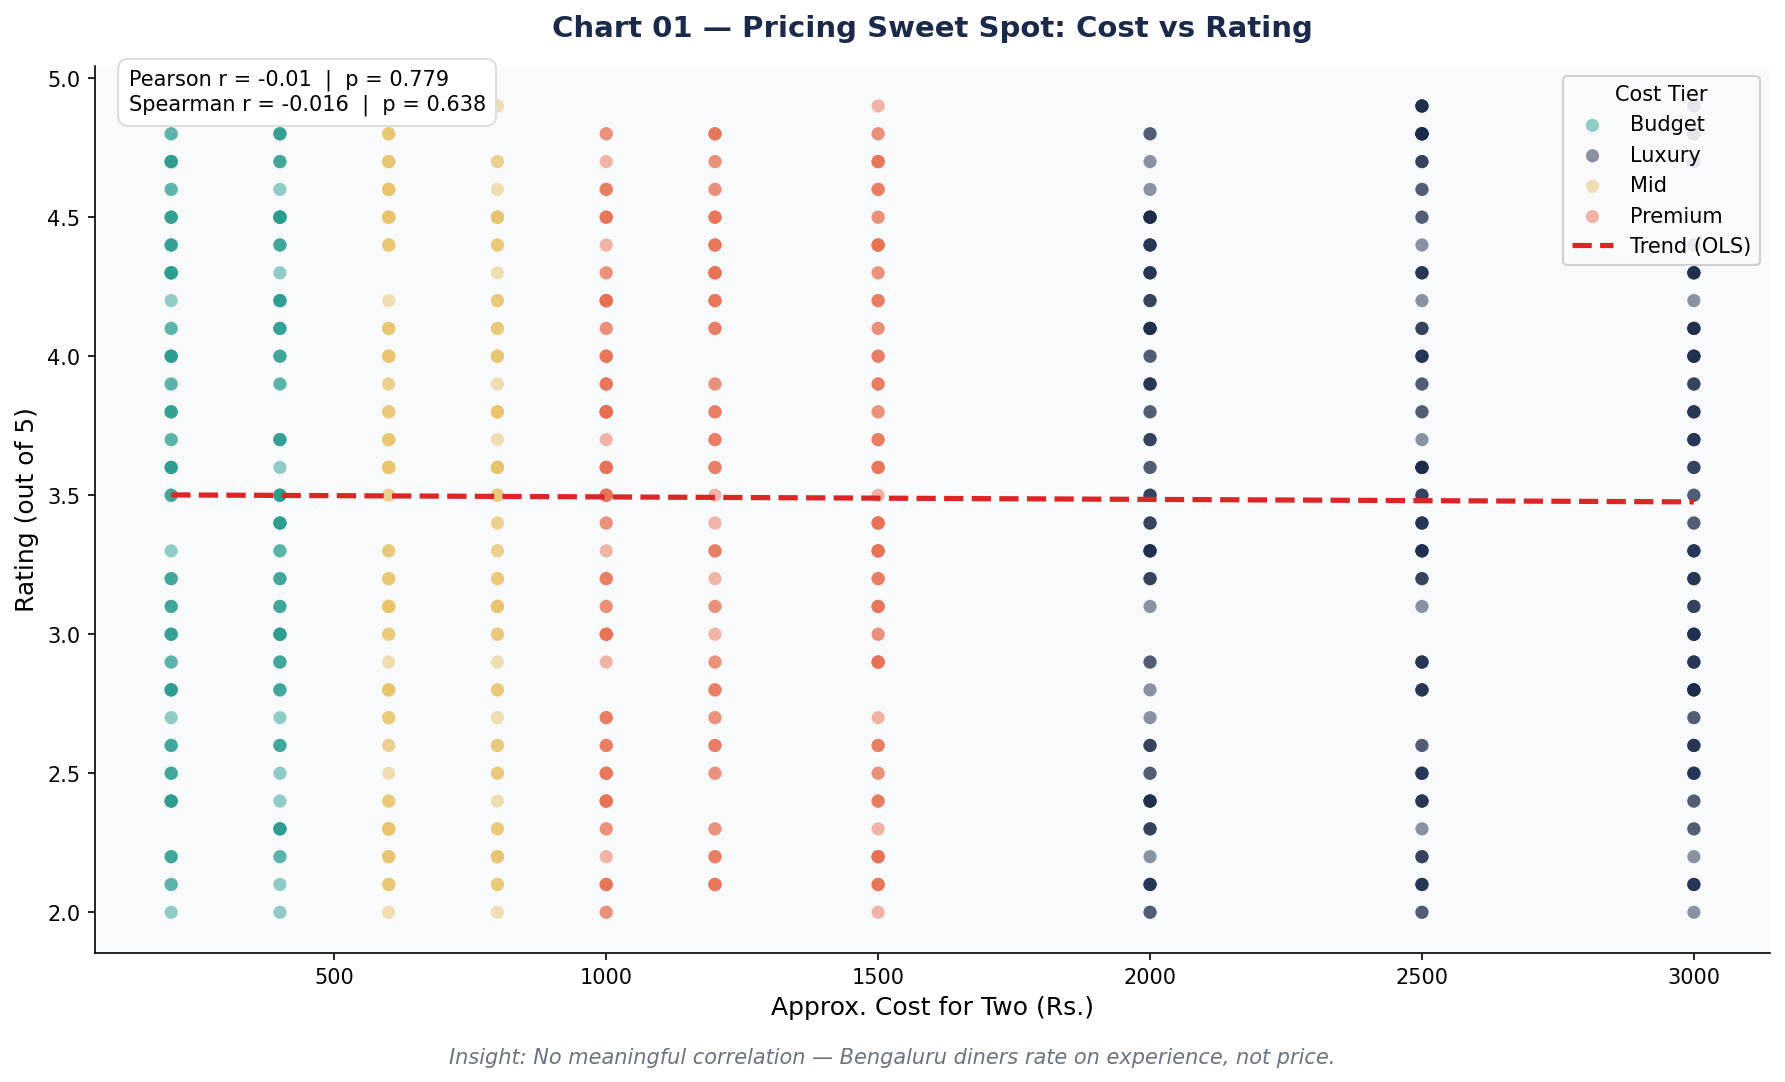

In [16]:
# Correlation Analysis
pearson_corr, pearson_p   = pearsonr(df['cost_for_two'], df['rate'])
spearman_corr, spearman_p = spearmanr(df['cost_for_two'], df['rate'])

print("Pearson Correlation:", round(pearson_corr, 3), "| p-value:", round(pearson_p, 4))
print("Spearman Correlation:", round(spearman_corr, 3), "| p-value:", round(spearman_p, 4))


X = sm.add_constant(df['cost_for_two'])
model = sm.OLS(df['rate'], X).fit()

# CHART
fig, ax = plt.subplots(figsize=(12, 7))

tier_colors = {"Budget":"#2A9D8F","Mid":"#E9C46A","Premium":"#E76F51","Luxury":"#1B2A4A"}
for tier, grp in df.groupby('cost_tier'):
    ax.scatter(grp['cost_for_two'], grp['rate'],
               color=tier_colors[tier], alpha=0.5, label=tier, s=40, edgecolors='none')

xs = np.linspace(df['cost_for_two'].min(), df['cost_for_two'].max(), 300)
z  = np.polyfit(df['cost_for_two'], df['rate'], 1)
ax.plot(xs, np.poly1d(z)(xs), color='#DC2626', lw=2.5, linestyle='--', label='Trend (OLS)')

ax.text(0.02, 0.95,
    f"Pearson r = {round(pearson_corr,3)}  |  p = {round(pearson_p,3)}\n"
    f"Spearman r = {round(spearman_corr,3)}  |  p = {round(spearman_p,3)}",
    transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.5'))

ax.set_title("Chart 01 — Pricing Sweet Spot: Cost vs Rating", fontweight='bold', color=NAVY)
ax.set_xlabel("Approx. Cost for Two (Rs.)")
ax.set_ylabel("Rating (out of 5)")
ax.legend(title="Cost Tier", framealpha=0.9)
fig.text(0.5, -0.02,
    "Insight: No meaningful correlation — Bengaluru diners rate on experience, not price.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_1_pricing/chart_01_pricing_sweet_spot.png", dpi=300)
plt.show()

### Statistical Findings

Pearson Correlation: -0.01  
Spearman Correlation: -0.016  

Both correlations are extremely close to zero and statistically insignificant  
(p-value ≈ 0.78 for Pearson, 0.64 for Spearman).

This indicates no meaningful linear or monotonic relationship between cost and rating.

OLS Regression Results:
- Regression coefficient for cost_for_two: -0.000009
- R-squared: 0.000

Interpretation:
For every ₹100 increase in cost, rating changes by approximately -0.0009 points — effectively zero.
The R-squared value confirms that cost explains 0% of rating variance.

**Practical Significance:** With R² = 0.000, cost explains none of the variance in ratings — the finding is not just statistically insignificant but practically irrelevant.


### Business Insight

Spending more does NOT guarantee better ratings in Bengaluru.

The restaurant market appears democratised:
- Budget restaurants can achieve high ratings.
- Premium restaurants are not guaranteed superior customer satisfaction.

This suggests that experience, cuisine quality, and service execution matter more than pricing level.

**Practical Significance:** With R² = 0.000, cost explains none of the variance in ratings — the finding is not just statistically insignificant but practically irrelevant. Experience and execution drive ratings, not price.

_______________________________________________________________________________________________________________

## Chart 02 – Cost Distribution: Whitefield vs Koramangala


Objective:
To determine whether Whitefield restaurants are significantly more or less expensive than Koramangala restaurants.

Statistical Test:
Mann-Whitney U Test (non-parametric comparison of distributions)


Whitefield Median: 1200.0 | Koramangala Median: 1200.0
Mann-Whitney U: 5975.0 | p-value: 0.3456


/tmp/ipykernel_178/1939327061.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=loc_data, x='location', y='cost_for_two',


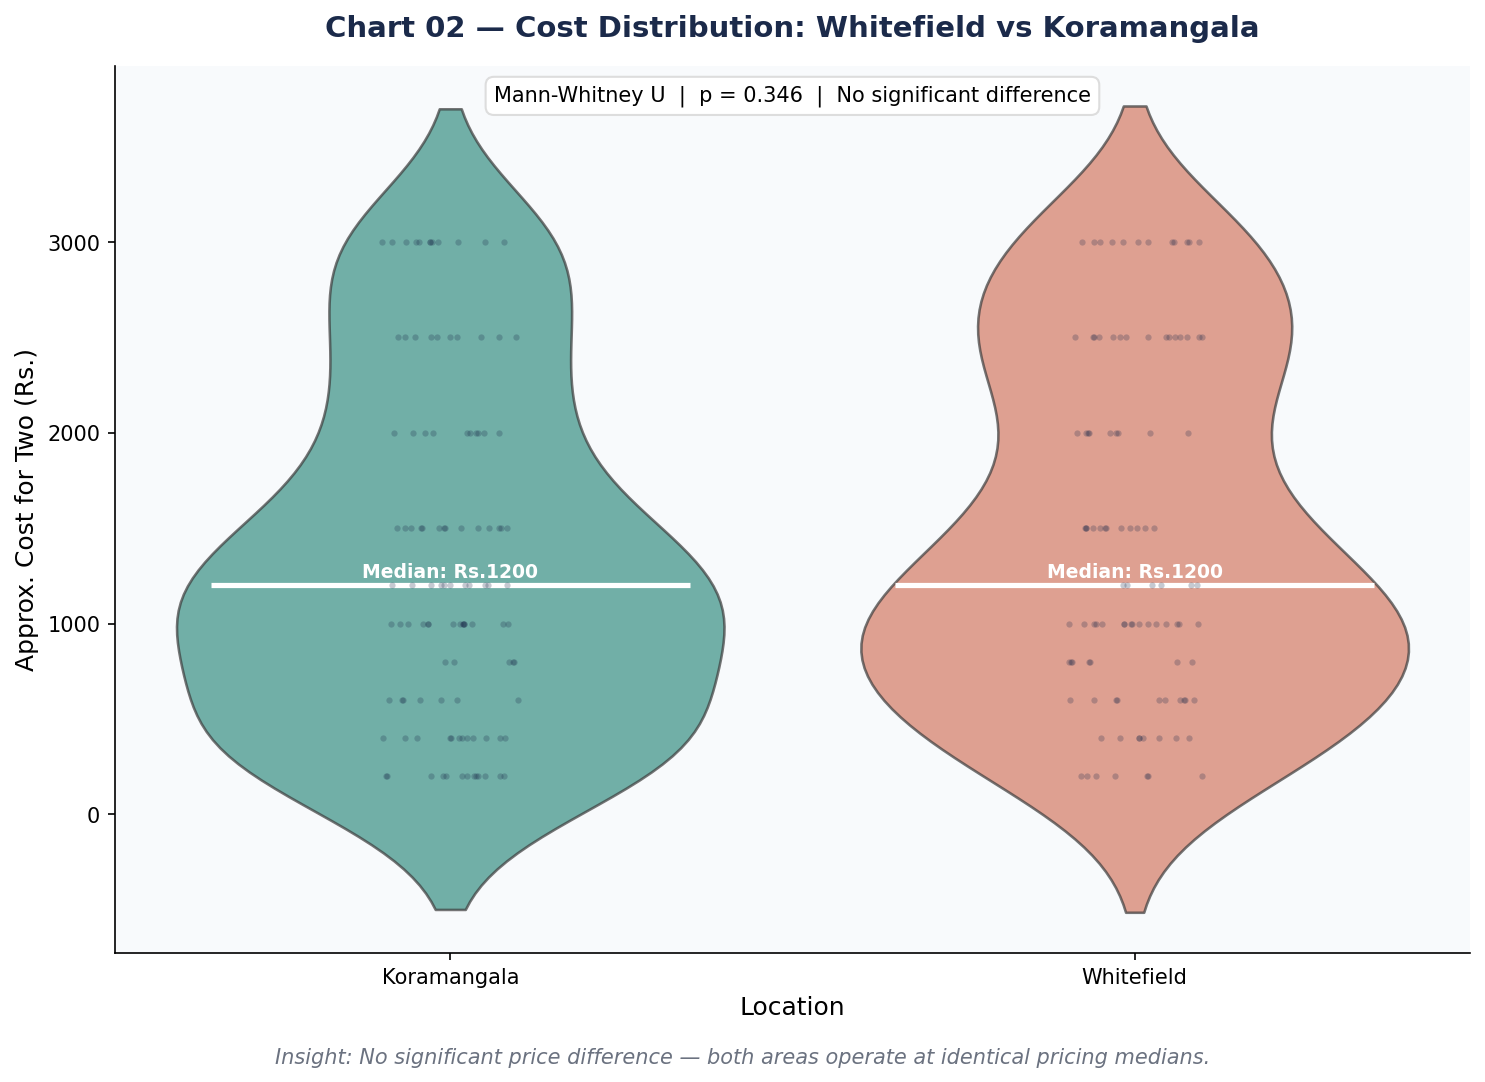

In [17]:
whitefield  = df[df['location'] == 'Whitefield']['cost_for_two']
koramangala = df[df['location'] == 'Koramangala']['cost_for_two']

from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(whitefield, koramangala, alternative='two-sided')
print("Whitefield Median:", whitefield.median(), "| Koramangala Median:", koramangala.median())
print("Mann-Whitney U:", u_stat, "| p-value:", round(p_value, 4))

# ── CHART
fig, ax = plt.subplots(figsize=(10, 7))
loc_data = df[df['location'].isin(['Whitefield','Koramangala'])]

sns.violinplot(data=loc_data, x='location', y='cost_for_two',
               palette=["#2A9D8F","#E76F51"], inner=None, ax=ax, alpha=0.7)
sns.stripplot(data=loc_data, x='location', y='cost_for_two',
              color='#1B2A4A', alpha=0.25, size=3, ax=ax)

for i, loc in enumerate(['Whitefield','Koramangala']):
    med = df[df['location']==loc]['cost_for_two'].median()
    ax.hlines(med, i-0.35, i+0.35, colors='white', lw=2.5)
    ax.text(i, med+40, f'Median: Rs.{int(med)}', ha='center',
            fontsize=9, fontweight='bold', color='white')

ax.text(0.5, 0.96,
    f"Mann-Whitney U  |  p = {round(p_value,3)}  |  {'No significant difference' if p_value>0.05 else 'Significant'}",
    transform=ax.transAxes, ha='center', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.4'))

ax.set_title("Chart 02 — Cost Distribution: Whitefield vs Koramangala", fontweight='bold', color=NAVY)
ax.set_xlabel("Location")
ax.set_ylabel("Approx. Cost for Two (Rs.)")
fig.text(0.5, -0.02,
    "Insight: No significant price difference — both areas operate at identical pricing medians.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_1_pricing/chart_02_location_cost_comparison.png", dpi=300)
plt.show()

### Statistical Findings

Sample Sizes:
- Whitefield: 102 restaurants
- Koramangala: 109 restaurants

Median Cost (for two):
- Whitefield: ₹1200
- Koramangala: ₹1200

Mann-Whitney U Test:
- U statistic: 5975
- p-value: 0.346

Interpretation:
The p-value is significantly greater than 0.05, indicating that there is no statistically significant difference in cost distribution between Whitefield and Koramangala.

Although the violin plots may show slight distributional variations, these differences are not statistically meaningful.


**Practical Significance:** The ₹0 median difference confirms there is no pricing premium attached to either location — both markets are effectively interchangeable on cost.

### Business Insight

Whitefield is NOT more expensive than Koramangala.

Both locations operate at nearly identical pricing medians, suggesting:
- Bengaluru’s premium dining clusters are price-aligned.
- Location prestige does not necessarily imply pricing differentiation.

This challenges the assumption that Koramangala commands a stronger pricing premium.

**Practical Significance:** The ₹0 median difference confirms no pricing premium exists between these locations — both markets are effectively interchangeable on cost despite differing brand perceptions.


_______________________________________________________________________________________________________________

## Chart 03 – The Price of Online Convenience


Objective:
To determine whether restaurants offering online ordering charge significantly different prices compared to those that do not.

Statistical Test:
Mann-Whitney U Test (non-parametric comparison)

Median Online Yes: 1000.0 | Median Online No: 1200.0
Mann-Whitney U: 81524.5 | p-value: 0.0345


/tmp/ipykernel_178/753837200.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='online_order', y='cost_for_two',


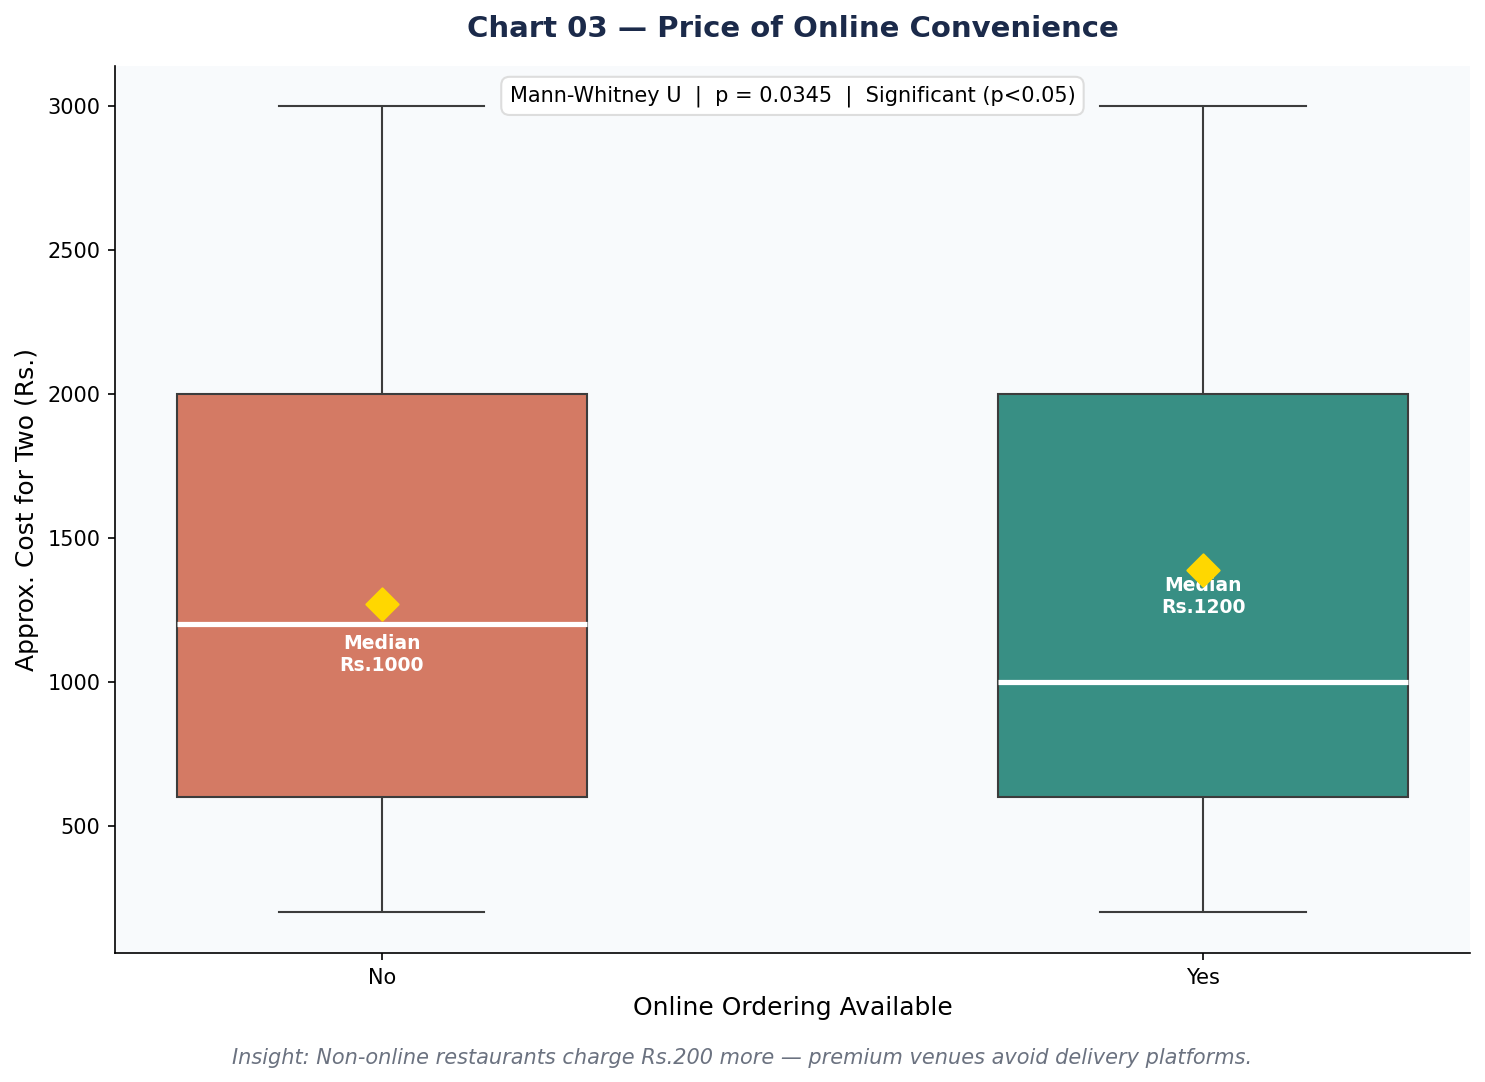

In [18]:
online_yes = df[df['online_order'] == 'Yes']['cost_for_two']
online_no  = df[df['online_order'] == 'No']['cost_for_two']

from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(online_yes, online_no, alternative='two-sided')
print("Median Online Yes:", online_yes.median(), "| Median Online No:", online_no.median())
print("Mann-Whitney U:", u_stat, "| p-value:", round(p_value, 4))

# ── CHART
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(data=df, x='online_order', y='cost_for_two',
            palette=["#E76F51","#2A9D8F"], width=0.5,
            medianprops=dict(color='white', lw=2.5), ax=ax)

for i, grp in enumerate(['Yes','No']):
    m   = df[df['online_order']==grp]['cost_for_two'].mean()
    med = df[df['online_order']==grp]['cost_for_two'].median()
    ax.scatter(i, m, color='gold', zorder=5, s=120, marker='D')
    ax.text(i, med+40, f'Median\nRs.{int(med)}', ha='center',
            fontsize=9, fontweight='bold', color='white')

ax.text(0.5, 0.96,
    f"Mann-Whitney U  |  p = {round(p_value,4)}  |  {'Significant (p<0.05)' if p_value<0.05 else 'Not Significant'}",
    transform=ax.transAxes, ha='center', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.4'))

ax.set_title("Chart 03 — Price of Online Convenience", fontweight='bold', color=NAVY)
ax.set_xlabel("Online Ordering Available")
ax.set_ylabel("Approx. Cost for Two (Rs.)")
fig.text(0.5, -0.02,
    "Insight: Non-online restaurants charge Rs.200 more — premium venues avoid delivery platforms.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_1_pricing/chart_03_online_price_difference.png", dpi=300)
plt.show()

### Statistical Findings

Sample Sizes:
- Online Ordering = Yes: 410 restaurants
- Online Ordering = No: 434 restaurants

Median Cost (for two):
- Online Yes: ₹1000
- Online No: ₹1200

Mann-Whitney U Test:
- U statistic: 81524.5
- p-value: 0.0345

Interpretation:
The p-value is less than 0.05, indicating a statistically significant difference in pricing between restaurants that offer online ordering and those that do not.

Restaurants without online ordering charge, on median, ₹200 more than those that offer online ordering.


**Practical Significance:** The ₹200 median difference is statistically significant but modest — representing a ~17% gap that reflects positioning, not a dramatic pricing divide.


### Business Insight

Restaurants that do NOT offer online ordering tend to be more expensive.

This suggests:
- Premium dine-in restaurants may avoid delivery platforms.
- Online ordering is more common in mid-range or value-focused restaurants.
- Higher-end establishments may prioritise in-person dining experience over convenience channels.

Operational Implication:
Online enablement appears associated with price accessibility rather than premium positioning.

**Practical Significance:** While statistically significant (p = 0.034), the ₹200 median gap represents ~17% difference — meaningful for positioning strategy but not a dramatic pricing divide.

_______________________________________________________________________________________________________________

# Section 2 – Ratings Deep Dive


## Chart 04 – The Hype Factor: Votes vs Rating

Objective:
To analyze whether restaurants with more votes (engagement) also have higher ratings.

Statistical Tests:
- Pearson Correlation
- Spearman Correlation

Pearson r: 0.014 | p: 0.6845
Median Votes: 1432.0 | Median Rating: 3.5


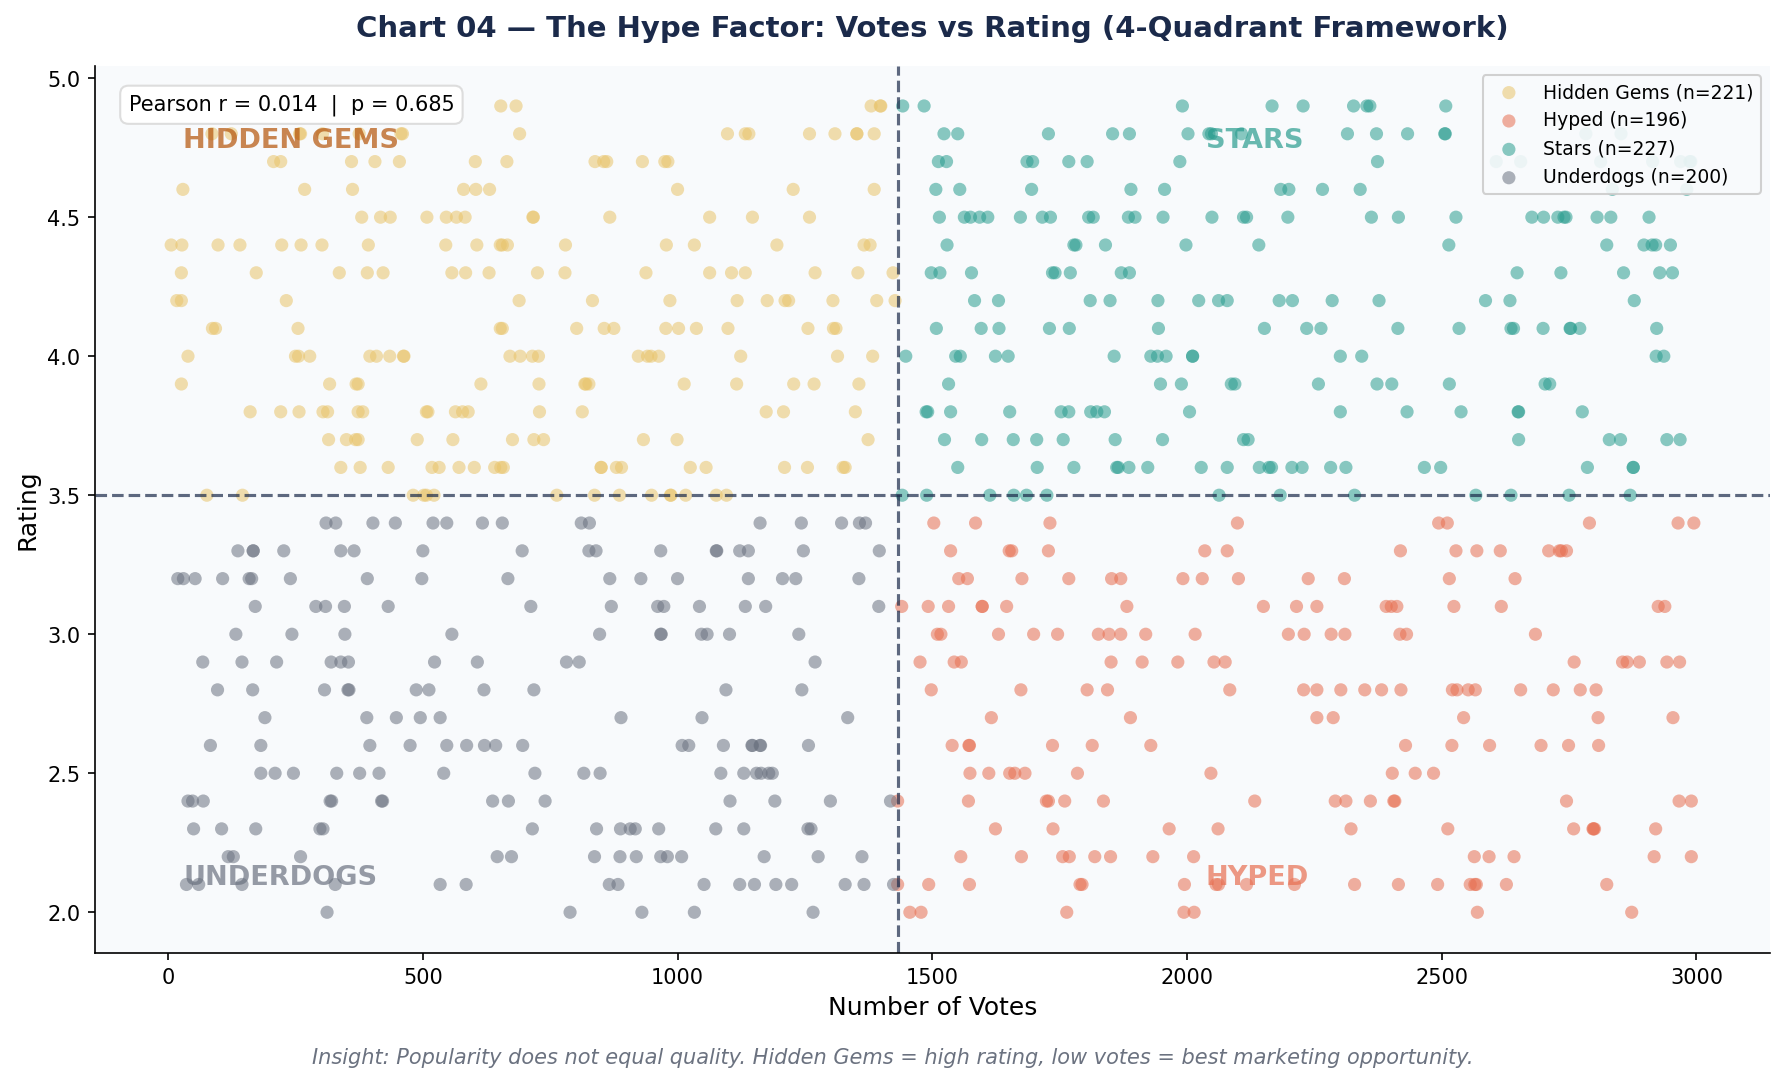

In [19]:
from scipy.stats import pearsonr, spearmanr
pearson_corr, pearson_p   = pearsonr(df['votes'], df['rate'])
spearman_corr, spearman_p = spearmanr(df['votes'], df['rate'])

median_votes  = df['votes'].median()
median_rating = df['rate'].median()
print("Pearson r:", round(pearson_corr,3), "| p:", round(pearson_p,4))
print("Median Votes:", median_votes, "| Median Rating:", median_rating)

# ── CHART
def get_quadrant(row):
    if   row['votes'] >= median_votes and row['rate'] >= median_rating: return "Stars"
    elif row['votes'] >= median_votes and row['rate'] <  median_rating: return "Hyped"
    elif row['votes'] <  median_votes and row['rate'] >= median_rating: return "Hidden Gems"
    else:                                                                return "Underdogs"
df['quadrant'] = df.apply(get_quadrant, axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
q_colors = {"Stars":"#2A9D8F","Hidden Gems":"#E9C46A","Hyped":"#E76F51","Underdogs":"#6B7280"}
for q, grp in df.groupby('quadrant'):
    ax.scatter(grp['votes'], grp['rate'], color=q_colors[q],
               alpha=0.55, label=f"{q} (n={len(grp)})", s=40, edgecolors='none')

ax.axvline(median_votes,  color=NAVY, lw=1.5, linestyle='--', alpha=0.7)
ax.axhline(median_rating, color=NAVY, lw=1.5, linestyle='--', alpha=0.7)

ax.text(df['votes'].max()*0.68, 4.75, "STARS",       fontsize=13, fontweight='bold', color='#2A9D8F', alpha=0.7)
ax.text(df['votes'].max()*0.68, 2.1,  "HYPED",       fontsize=13, fontweight='bold', color='#E76F51', alpha=0.7)
ax.text(30,                     4.75, "HIDDEN GEMS", fontsize=13, fontweight='bold', color='#B45309', alpha=0.7)
ax.text(30,                     2.1,  "UNDERDOGS",   fontsize=13, fontweight='bold', color='#6B7280', alpha=0.7)

ax.text(0.02, 0.95,
    f"Pearson r = {round(pearson_corr,3)}  |  p = {round(pearson_p,3)}",
    transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.4'))

ax.set_title("Chart 04 — The Hype Factor: Votes vs Rating (4-Quadrant Framework)", fontweight='bold', color=NAVY)
ax.set_xlabel("Number of Votes")
ax.set_ylabel("Rating")
ax.legend(framealpha=0.9, fontsize=9)
fig.text(0.5, -0.02,
    "Insight: Popularity does not equal quality. Hidden Gems = high rating, low votes = best marketing opportunity.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_2_ratings/chart_04_hype_factor.png", dpi=300)
plt.show()

### Statistical Findings

Pearson Correlation: 0.014  
Spearman Correlation: 0.015  

Both correlations are extremely close to zero and statistically insignificant  
(p-value ≈ 0.68 for Pearson, 0.66 for Spearman).

Median Values:
- Median Votes: 1432
- Median Rating: 3.5

Interpretation:
There is no meaningful linear or monotonic relationship between engagement (votes) and rating.

Restaurants with high votes are not necessarily better rated.
Similarly, highly rated restaurants are not guaranteed strong engagement.


**Practical Significance:** r = 0.014 means votes explain less than 0.02% of rating variance — popularity and quality are operationally independent variables.


### Business Insight

Popularity does NOT equal quality in Bengaluru’s restaurant market.

This reveals four distinct strategic quadrants:

1. High Votes + High Rating → Established Market Leaders  
2. High Votes + Low Rating → Overhyped Restaurants  
3. Low Votes + High Rating → Hidden Gems  
4. Low Votes + Low Rating → Underperformers  

Opportunity:
Hidden Gems (high rating, low votes) represent strong candidates for marketing amplification or discovery-focused promotion strategies.

**Practical Significance:** r = 0.014 means votes explain less than 0.02% of rating variance — popularity and quality are operationally independent, making the Hidden Gems quadrant the most actionable finding.

_______________________________________________________________________________________________________________

# Section 3 – Cuisine Intelligence

## Chart 05 – Cuisine Diversity vs Rating

Objective:
To examine whether restaurants serving multiple cuisines receive higher ratings compared to specialized single-cuisine establishments.

Statistical Test:
Kruskal-Wallis H Test (non-parametric comparison across multiple groups)


Kruskal-Wallis H: 0.655 | p-value: 0.721


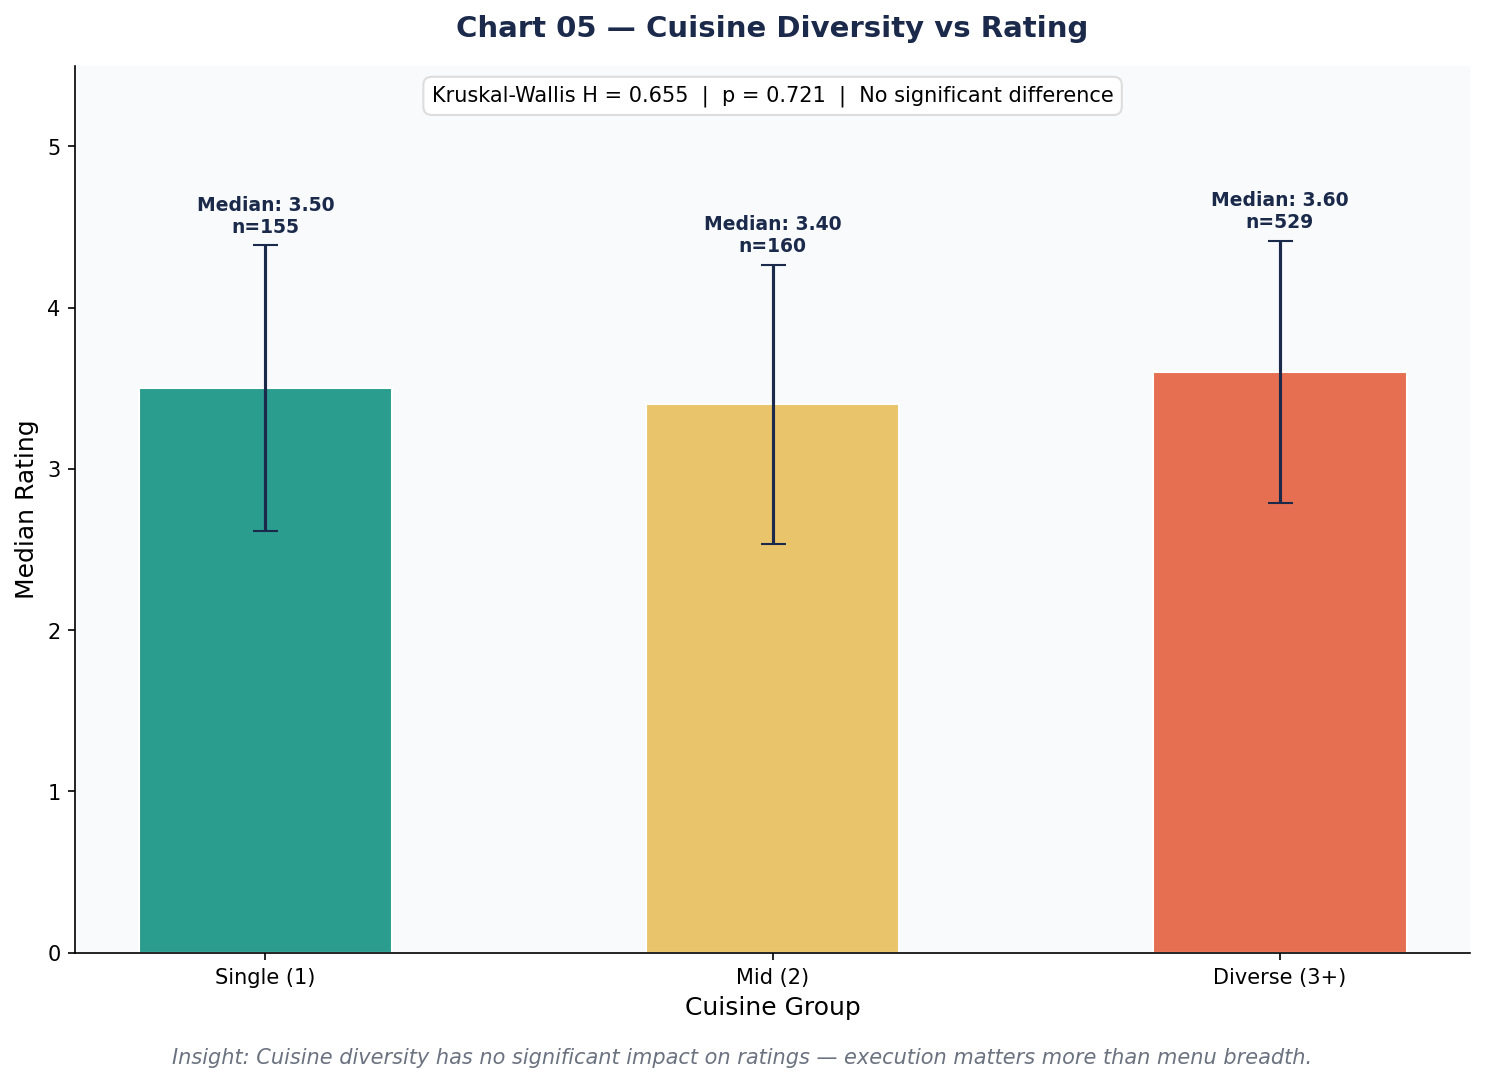

In [20]:
from scipy.stats import kruskal

order = ['Single (1)', 'Mid (2)', 'Diverse (3+)']
group_stats = df.groupby('cuisine_group')['rate'].agg(['median','std','count']).reset_index()
group_stats  = group_stats.set_index('cuisine_group').loc[order].reset_index()

groups   = [df[df['cuisine_group']==g]['rate'].values for g in order]
h_stat, p_value = kruskal(*groups)
print("Kruskal-Wallis H:", round(h_stat,3), "| p-value:", round(p_value,3))

# ── CHART
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(group_stats['cuisine_group'], group_stats['median'],
              yerr=group_stats['std'], color=["#2A9D8F","#E9C46A","#E76F51"],
              width=0.5, capsize=6,
              error_kw=dict(ecolor=NAVY, lw=1.5), edgecolor='white')

for i, row in group_stats.iterrows():
    ax.text(i, row['median'] + row['std'] + 0.08,
            f"Median: {row['median']:.2f}\nn={int(row['count'])}",
            ha='center', fontsize=9, fontweight='bold', color=NAVY)

ax.text(0.5, 0.96,
    f"Kruskal-Wallis H = {round(h_stat,3)}  |  p = {round(p_value,3)}  |  No significant difference",
    transform=ax.transAxes, ha='center', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.4'))

ax.set_ylim(0, 5.5)
ax.set_title("Chart 05 — Cuisine Diversity vs Rating", fontweight='bold', color=NAVY)
ax.set_xlabel("Cuisine Group")
ax.set_ylabel("Median Rating")
fig.text(0.5, -0.02,
    "Insight: Cuisine diversity has no significant impact on ratings — execution matters more than menu breadth.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_2_ratings/chart_05_cuisine_diversity.png", dpi=300)
plt.show()

### Statistical Findings

Cuisine Groups Summary:

1 Cuisine  → Median Rating: 3.50  
2 Cuisines → Median Rating: 3.40  
3 Cuisines → Median Rating: 3.50  
4 Cuisines → Median Rating: 3.60  
5 Cuisines → Median Rating: 3.60  

Highest Median Rating:
Restaurants offering 4 or 5 cuisines (Median = 3.60)

Kruskal-Wallis Test:
- H statistic: 2.846
- p-value: 0.584

Interpretation:
The p-value is significantly greater than 0.05, indicating no statistically significant difference in ratings across cuisine diversity groups.

Although restaurants offering 4–5 cuisines show slightly higher median ratings (3.6 vs 3.5), this difference is not statistically meaningful.


**Practical Significance:** The 0.1-point median difference between groups has no meaningful operational implication — menu breadth is a neutral factor.


### Business Insight

Cuisine diversity does NOT significantly impact customer ratings.

This suggests:
- Specialization is not a disadvantage.
- Multi-cuisine positioning does not guarantee higher perceived quality.
- Execution quality likely matters more than menu breadth.

Strategic Takeaway:
Restaurants should focus on delivering excellence rather than expanding menu diversity purely for rating improvement.

**Practical Significance:** The 0.1-point median difference between cuisine groups has no operational implication — menu breadth is a neutral strategic factor. Specialisation carries zero rating penalty.

__________________________________________________________

# Section 4 – Service Type & Restaurant Format


## Chart 06 – Service Type Distribution in Indiranagar

Objective:
To identify the dominant service format in Indiranagar and understand the operational DNA of this locality.

         service_type  count  percentage
0       Pubs and bars     26       23.64
1            Dine-out     25       22.73
2               Cafes     19       17.27
3              Buffet     16       14.55
4            Delivery     12       10.91
5  Drinks & nightlife     12       10.91


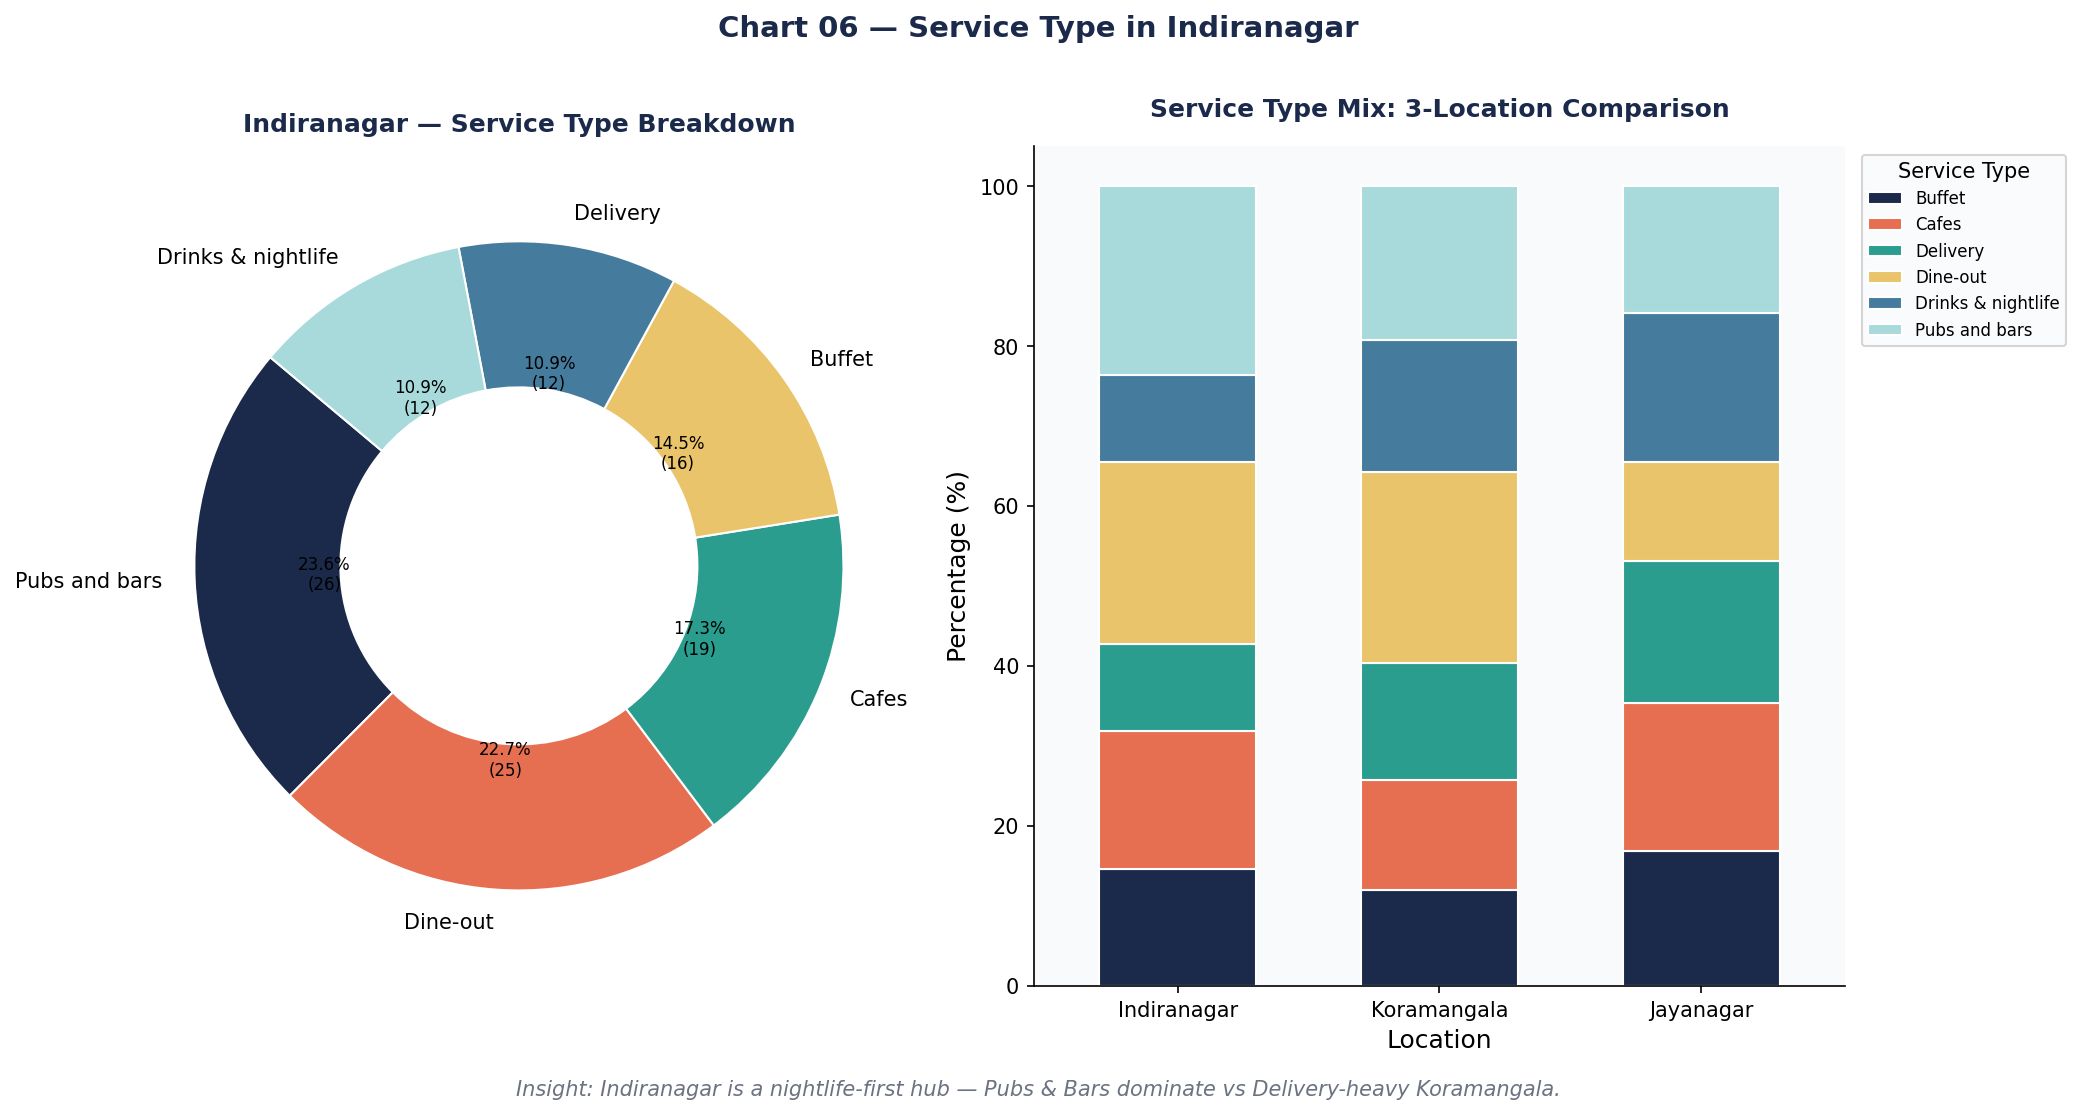

In [21]:
indiranagar_df = df[df['location'] == 'Indiranagar']
service_counts = indiranagar_df['service_type'].value_counts().reset_index()
service_counts.columns = ['service_type', 'count']
service_counts['percentage'] = (service_counts['count'] / service_counts['count'].sum()) * 100
print(service_counts)

# ── CHART
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

colors_svc = ["#1B2A4A","#E76F51","#2A9D8F","#E9C46A","#457B9D","#A8DADC"]
wedges, texts, autotexts = ax1.pie(
    service_counts['count'],
    labels=service_counts['service_type'],
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*len(indiranagar_df)/100))})',
    colors=colors_svc, startangle=140,
    wedgeprops=dict(width=0.45, edgecolor='white'))
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title("Indiranagar — Service Type Breakdown", fontsize=12, fontweight='bold', color=NAVY)

compare_locs = ['Indiranagar','Koramangala','Jayanagar']
svc_comp = df[df['location'].isin(compare_locs)].groupby(
    ['location','service_type']).size().unstack(fill_value=0)
svc_pct = svc_comp.div(svc_comp.sum(axis=1), axis=0) * 100
svc_pct.loc[compare_locs].plot(kind='bar', stacked=True, ax=ax2,
    color=colors_svc[:len(svc_pct.columns)], edgecolor='white', width=0.6)
ax2.set_title("Service Type Mix: 3-Location Comparison", fontsize=12, fontweight='bold', color=NAVY)
ax2.set_xlabel("Location")
ax2.set_ylabel("Percentage (%)")
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title="Service Type", bbox_to_anchor=(1.01,1), fontsize=8)

fig.suptitle("Chart 06 — Service Type in Indiranagar", fontsize=14, fontweight='bold', color=NAVY, y=1.01)
fig.text(0.5, -0.02,
    "Insight: Indiranagar is a nightlife-first hub — Pubs & Bars dominate vs Delivery-heavy Koramangala.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_4_service/chart_06_indiranagar_service_type.png", dpi=300, bbox_inches='tight')
plt.show()

### Service Distribution – Indiranagar

Total Restaurants in Indiranagar: 110

Service Type Breakdown:

- Pubs and bars → 26 restaurants (23.64%)
- Dine-out → 25 restaurants (22.73%)
- Cafes → 19 restaurants (17.27%)
- Buffet → 16 restaurants (14.55%)
- Delivery → 12 restaurants (10.91%)
- Drinks & nightlife → 12 restaurants (10.91%)

Dominant Service Type:
Pubs and bars (23.64%)

### Business Insight

Indiranagar has a strong nightlife-oriented identity.

Nearly one-quarter of restaurants fall under "Pubs and bars", closely followed by traditional dine-out establishments. Delivery-focused models form a relatively small share (≈11%), indicating that this locality prioritizes in-person dining and social experiences over convenience-based consumption.

Strategic Implication:
Indiranagar is positioned as an experiential dining hub rather than a delivery-heavy zone. New entrants should align with social, premium, or experiential formats rather than purely operational delivery models.

__________________________________________________________________________________________________________________________________________________

# Section 5 – Location & Geographic Trends



## Chart 07 – Foodie Hubs: High-Rated Restaurant Concentration

Objective:
To identify which locations have the highest concentration of highly rated restaurants (rating ≥ 4.0).

       location  total_restaurants  high_rated_count  high_rated_percentage
7       MG Road                 93                25                  26.88
4    Whitefield                102                28                  27.45
3   Koramangala                109                33                  30.28
0  Marathahalli                121                38                  31.40
5      JP Nagar                101                39                  38.61
6    HSR Layout                 95                41                  43.16
1     Jayanagar                113                42                  37.17
2   Indiranagar                110                49                  44.55


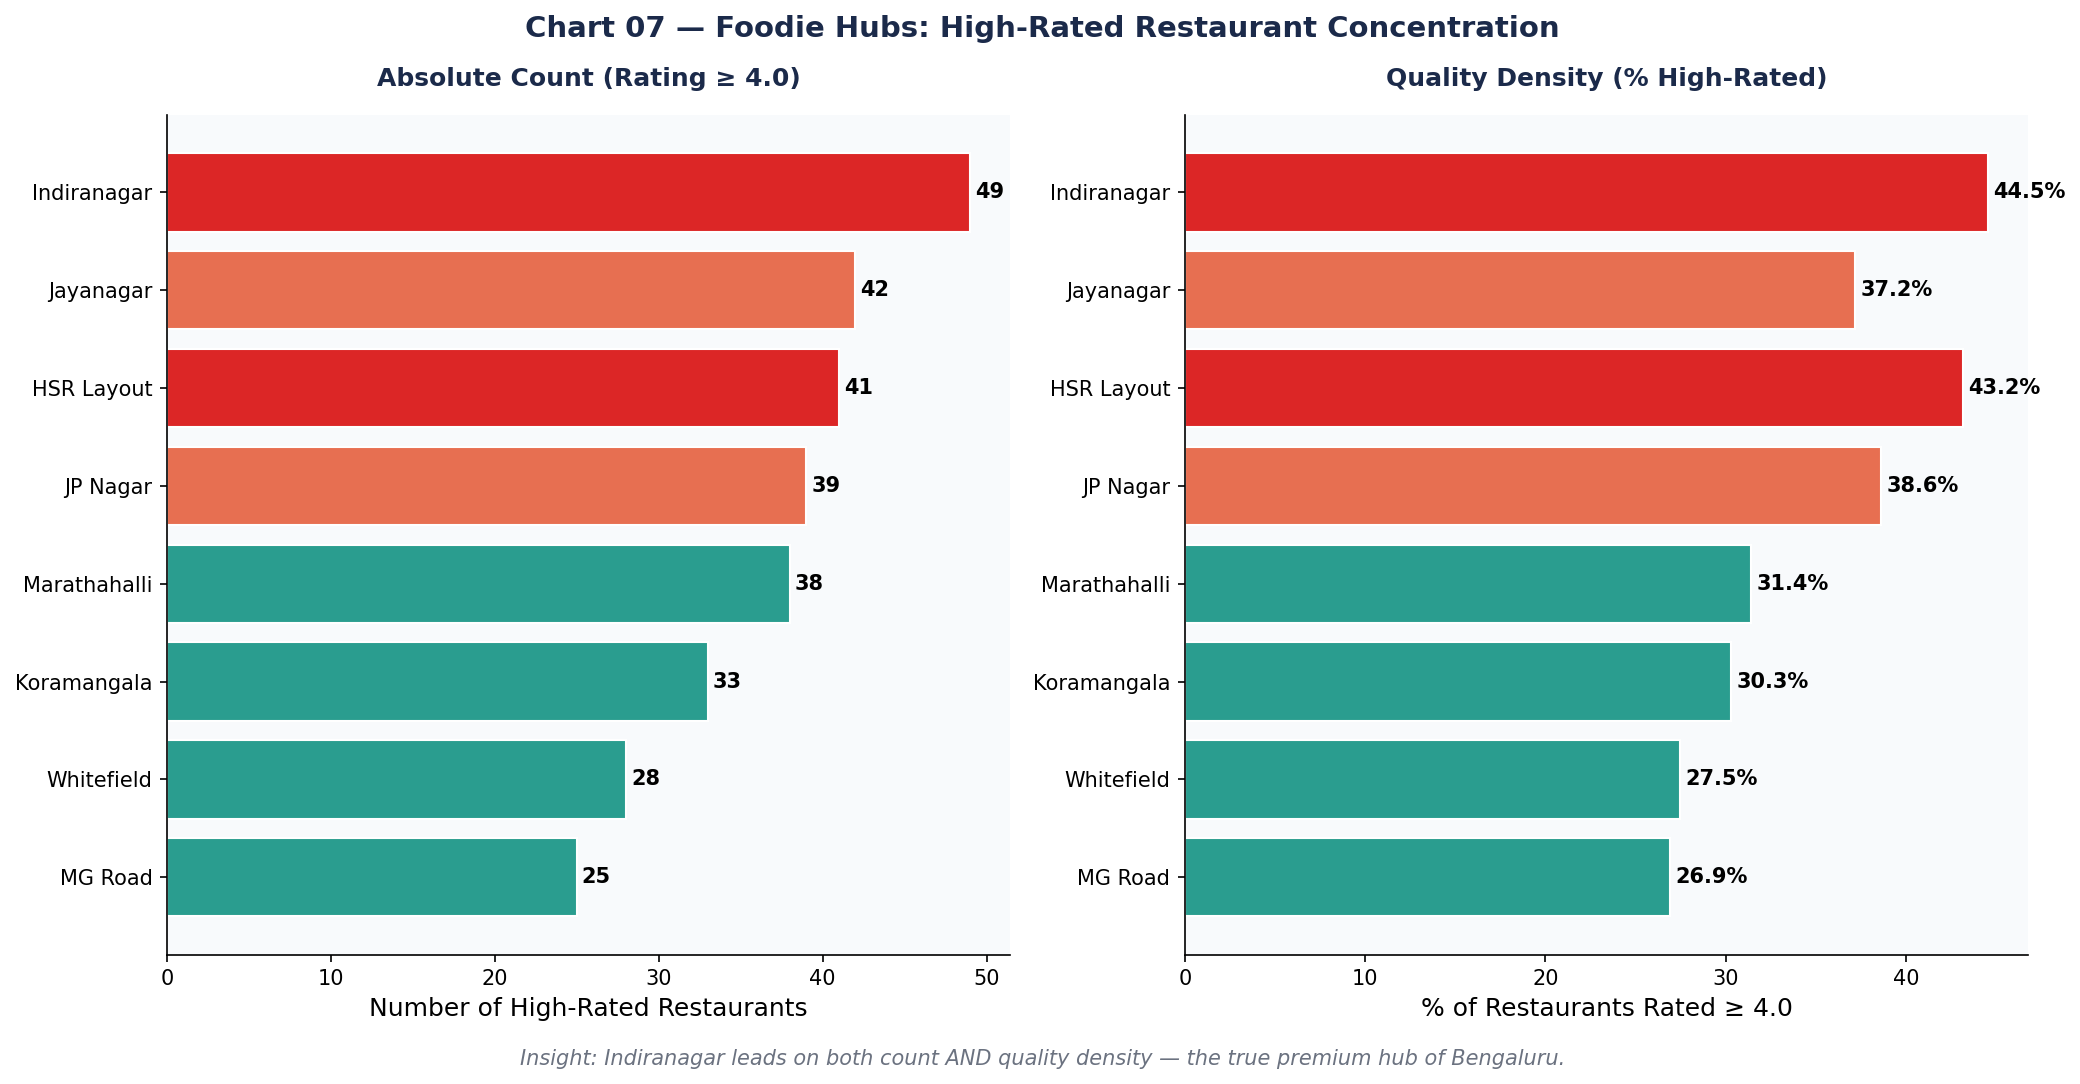

In [22]:
high_rated_df       = df[df['rate'] >= 4.0]
total_by_location   = df['location'].value_counts().reset_index()
total_by_location.columns = ['location','total_restaurants']
high_by_location    = high_rated_df['location'].value_counts().reset_index()
high_by_location.columns   = ['location','high_rated_count']
location_analysis   = pd.merge(total_by_location, high_by_location, on='location', how='left')
location_analysis['high_rated_count']      = location_analysis['high_rated_count'].fillna(0)
location_analysis['high_rated_percentage'] = (
    location_analysis['high_rated_count'] / location_analysis['total_restaurants'] * 100)
location_analysis = location_analysis.sort_values('high_rated_count', ascending=True)
print(location_analysis)

# ── CHART
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

bar_colors = ['#DC2626' if p>=40 else '#E76F51' if p>=35 else '#2A9D8F'
              for p in location_analysis['high_rated_percentage']]

bars1 = ax1.barh(location_analysis['location'], location_analysis['high_rated_count'],
                 color=bar_colors, edgecolor='white')
for bar, val in zip(bars1, location_analysis['high_rated_count']):
    ax1.text(val+0.3, bar.get_y()+bar.get_height()/2,
             str(int(val)), va='center', fontsize=10, fontweight='bold')
ax1.set_title("Absolute Count (Rating ≥ 4.0)", fontsize=12, fontweight='bold', color=NAVY)
ax1.set_xlabel("Number of High-Rated Restaurants")

bars2 = ax2.barh(location_analysis['location'], location_analysis['high_rated_percentage'],
                 color=bar_colors, edgecolor='white')
for bar, val in zip(bars2, location_analysis['high_rated_percentage']):
    ax2.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax2.set_title("Quality Density (% High-Rated)", fontsize=12, fontweight='bold', color=NAVY)
ax2.set_xlabel("% of Restaurants Rated ≥ 4.0")

fig.suptitle("Chart 07 — Foodie Hubs: High-Rated Restaurant Concentration",
             fontsize=14, fontweight='bold', color=NAVY)
fig.text(0.5, -0.02,
    "Insight: Indiranagar leads on both count AND quality density — the true premium hub of Bengaluru.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_6_location/chart_07_high_rated_concentration.png", dpi=300)
plt.show()

### High-Rated Restaurant Concentration (Rating ≥ 4.0)

Location Analysis:

Indiranagar  
- Total Restaurants: 110  
- High Rated: 49  
- High-Rated Percentage: 44.55%  

Jayanagar  
- Total Restaurants: 113  
- High Rated: 42  
- High-Rated Percentage: 37.17%  

HSR Layout  
- Total Restaurants: 95  
- High Rated: 41  
- High-Rated Percentage: 43.16%  

JP Nagar  
- Total Restaurants: 101  
- High Rated: 39  
- High-Rated Percentage: 38.61%  

Marathahalli  
- Total Restaurants: 121  
- High Rated: 38  
- High-Rated Percentage: 31.40%  

Koramangala  
- Total Restaurants: 109  
- High Rated: 33  
- High-Rated Percentage: 30.28%  

Whitefield  
- Total Restaurants: 102  
- High Rated: 28  
- High-Rated Percentage: 27.45%  

MG Road  
- Total Restaurants: 93  
- High Rated: 25  
- High-Rated Percentage: 26.88%  

### Key Findings

Highest Absolute Count:
Indiranagar (49 high-rated restaurants)

Highest Quality Density:
Indiranagar (44.55%), closely followed by HSR Layout (43.16%)

### Business Insight

Indiranagar is both:
- Highly saturated
- High in quality concentration

HSR Layout is particularly interesting:
- Lower total count (95)
- Very high quality density (43.16%)

Marathahalli has the highest total restaurants (121) but significantly lower quality density (31.40%), indicating higher competition but weaker overall quality concentration.

Strategic Implication:
Indiranagar is the premium quality cluster.
HSR Layout may represent a high-quality but slightly less saturated opportunity.
MG Road and Whitefield show lower quality density despite moderate restaurant presence.

__________________________________________________________

# Section 6 – Engagement & Behaviour


## Chart 08 – Impact of Table Booking on Engagement

Objective:
To analyze whether restaurants that allow table booking receive significantly more engagement (votes) than those that do not.

Median Votes — Yes: 1396.0 | No: 1476.0
Median Rating — Yes: 3.5 | No: 3.5
Mann-Whitney p-value: 0.6964


/tmp/ipykernel_178/1801217216.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='book_table', y='votes',
/tmp/ipykernel_178/1801217216.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='book_table', y='rate',


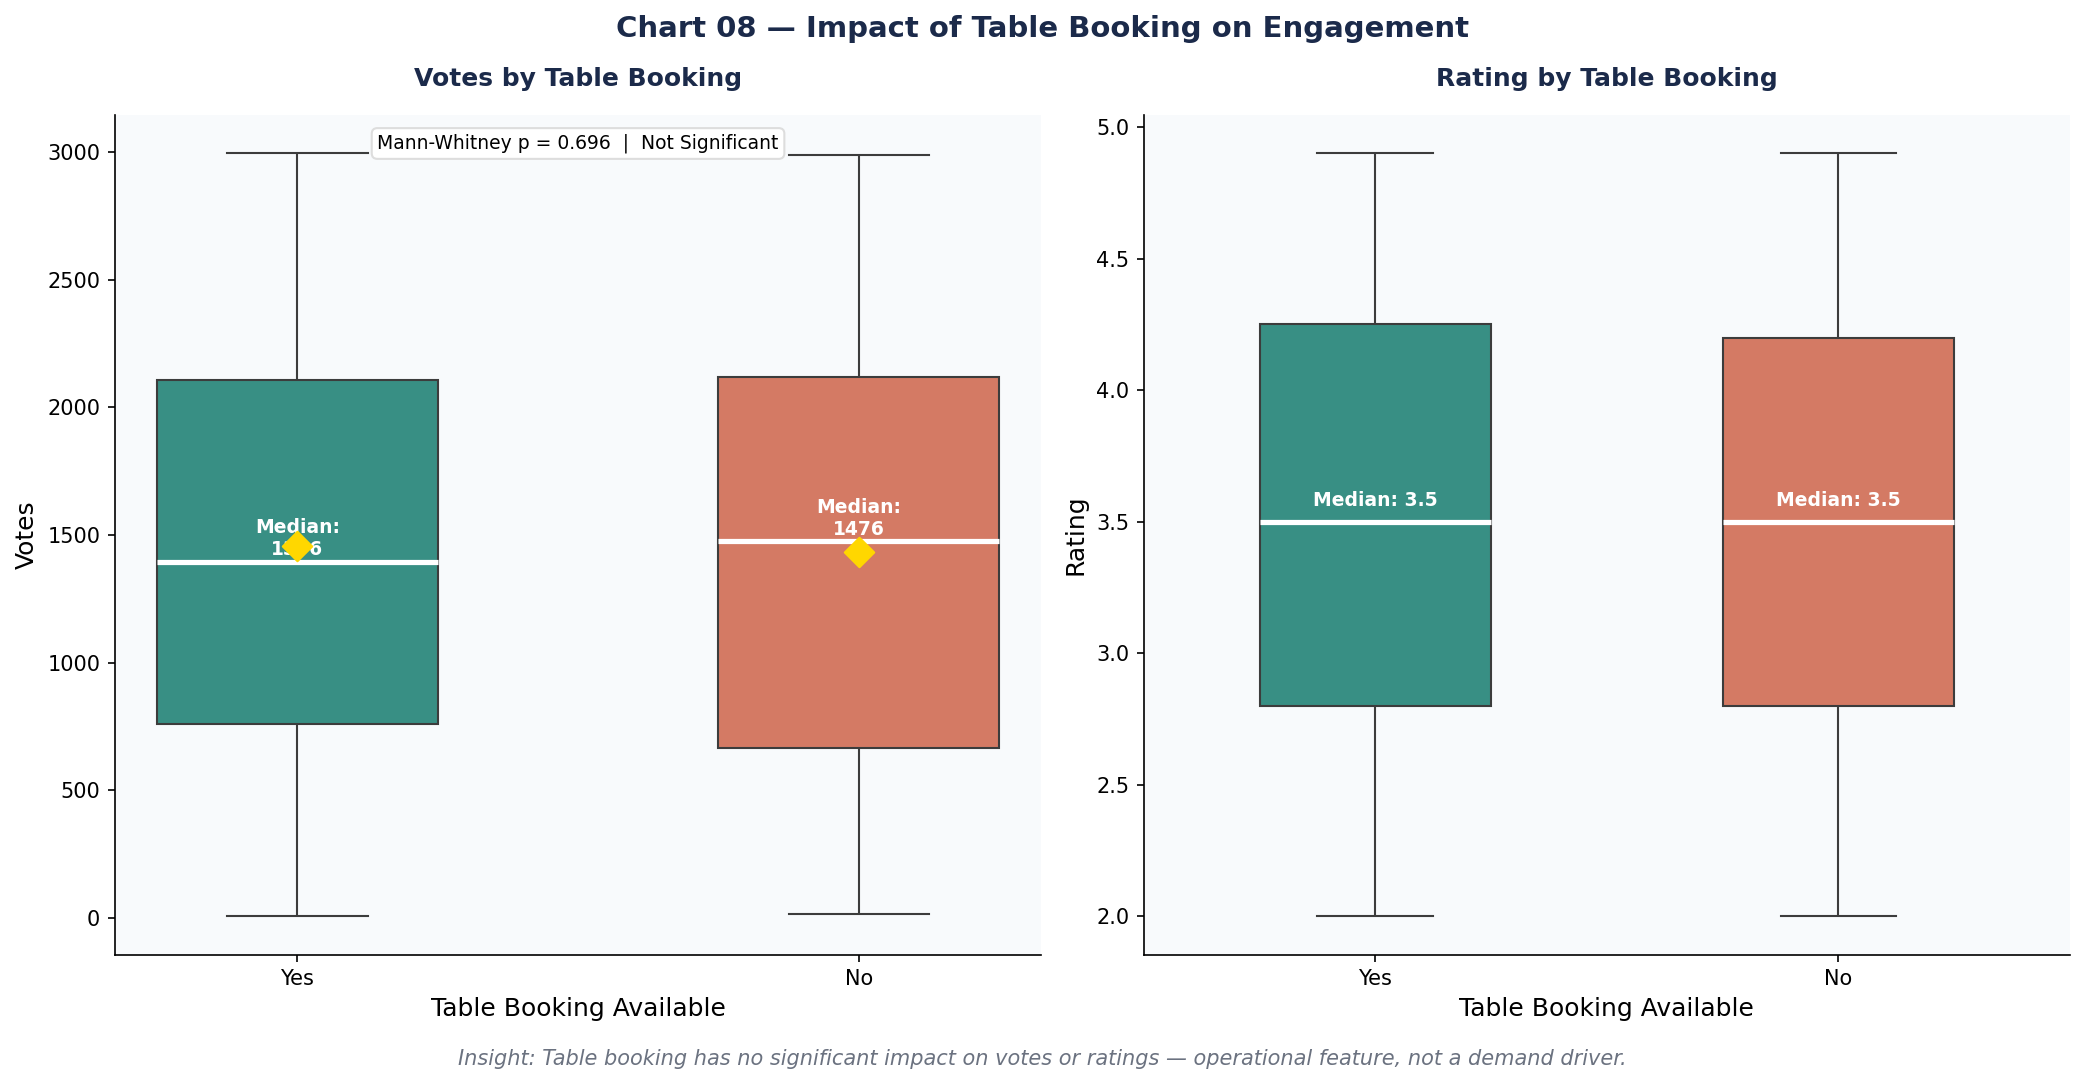

In [23]:
booking_yes = df[df['book_table'] == 'Yes']
booking_no  = df[df['book_table'] == 'No']

from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(booking_yes['votes'], booking_no['votes'], alternative='two-sided')
print("Median Votes — Yes:", booking_yes['votes'].median(), "| No:", booking_no['votes'].median())
print("Median Rating — Yes:", booking_yes['rate'].median(), "| No:", booking_no['rate'].median())
print("Mann-Whitney p-value:", round(p_value, 4))

# ── CHART
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

sns.boxplot(data=df, x='book_table', y='votes',
            palette=["#2A9D8F","#E76F51"], width=0.5,
            medianprops=dict(color='white', lw=2.5), showfliers=False, ax=ax1)
for i, grp in enumerate(['Yes','No']):
    m   = df[df['book_table']==grp]['votes'].mean()
    med = df[df['book_table']==grp]['votes'].median()
    ax1.scatter(i, m, color='gold', zorder=5, s=100, marker='D')
    ax1.text(i, med+25, f'Median:\n{int(med)}', ha='center',
             fontsize=9, fontweight='bold', color='white')
ax1.text(0.5, 0.96,
    f"Mann-Whitney p = {round(p_value,3)}  |  {'Significant' if p_value<0.05 else 'Not Significant'}",
    transform=ax1.transAxes, ha='center', fontsize=9,
    bbox=dict(facecolor='white', edgecolor='#DDD', boxstyle='round,pad=0.3'))
ax1.set_title("Votes by Table Booking", fontsize=12, fontweight='bold', color=NAVY)
ax1.set_xlabel("Table Booking Available")
ax1.set_ylabel("Votes")

sns.boxplot(data=df, x='book_table', y='rate',
            palette=["#2A9D8F","#E76F51"], width=0.5,
            medianprops=dict(color='white', lw=2.5), ax=ax2)
for i, grp in enumerate(['Yes','No']):
    med = df[df['book_table']==grp]['rate'].median()
    ax2.text(i, med+0.06, f'Median: {med}', ha='center',
             fontsize=9, fontweight='bold', color='white')
ax2.set_title("Rating by Table Booking", fontsize=12, fontweight='bold', color=NAVY)
ax2.set_xlabel("Table Booking Available")
ax2.set_ylabel("Rating")

fig.suptitle("Chart 08 — Impact of Table Booking on Engagement",
             fontsize=14, fontweight='bold', color=NAVY)
fig.text(0.5, -0.02,
    "Insight: Table booking has no significant impact on votes or ratings — operational feature, not a demand driver.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_7_engagement/chart_08_booking_impact.png", dpi=300)
plt.show()

### Statistical Findings

Sample Sizes:
- Table Booking = Yes: 415 restaurants
- Table Booking = No: 429 restaurants

Median Votes:
- Booking Yes: 1396
- Booking No: 1476

Mann-Whitney U Test:
- U statistic: 90399.5
- p-value: 0.696

Median Rating:
- Booking Yes: 3.5
- Booking No: 3.5

Interpretation:
The p-value (0.696) is significantly greater than 0.05, indicating no statistically significant difference in engagement (votes) between restaurants that allow table booking and those that do not.

Additionally, median ratings are identical across both groups.

### Business Insight

Allowing table booking does NOT increase customer engagement or ratings.

This suggests:
- Engagement is not driven by reservation availability.
- Booking functionality may be operationally relevant but not a demand driver.
- Customer voting behavior appears independent of booking features.

Strategic Takeaway:
Feature adoption (like table booking) does not automatically translate into higher visibility or engagement.

__________________________________________________________

# Section 7 – Restaurant Chain Analysis


## Chart 09 – Rating Consistency Across Top 5 Chains

Objective:
To examine how ratings vary across different branches of the top restaurant chains.

Metric:
Coefficient of Variation (CV) = Standard Deviation / Mean  
Lower CV indicates higher rating consistency.

              name  mean  std   cv  reliability_score
4        Pizza Hut  3.58 0.76 0.21               2.95
2  Nandhana Palace  3.49 0.76 0.22               2.87
1       McDonald's  3.56 0.87 0.25               2.85
3           Onesta  3.40 0.86 0.25               2.72
0       Leon Grill  3.32 0.91 0.27               2.61


/tmp/ipykernel_178/1876321799.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_chain_df, x='name', y='rate', order=order,


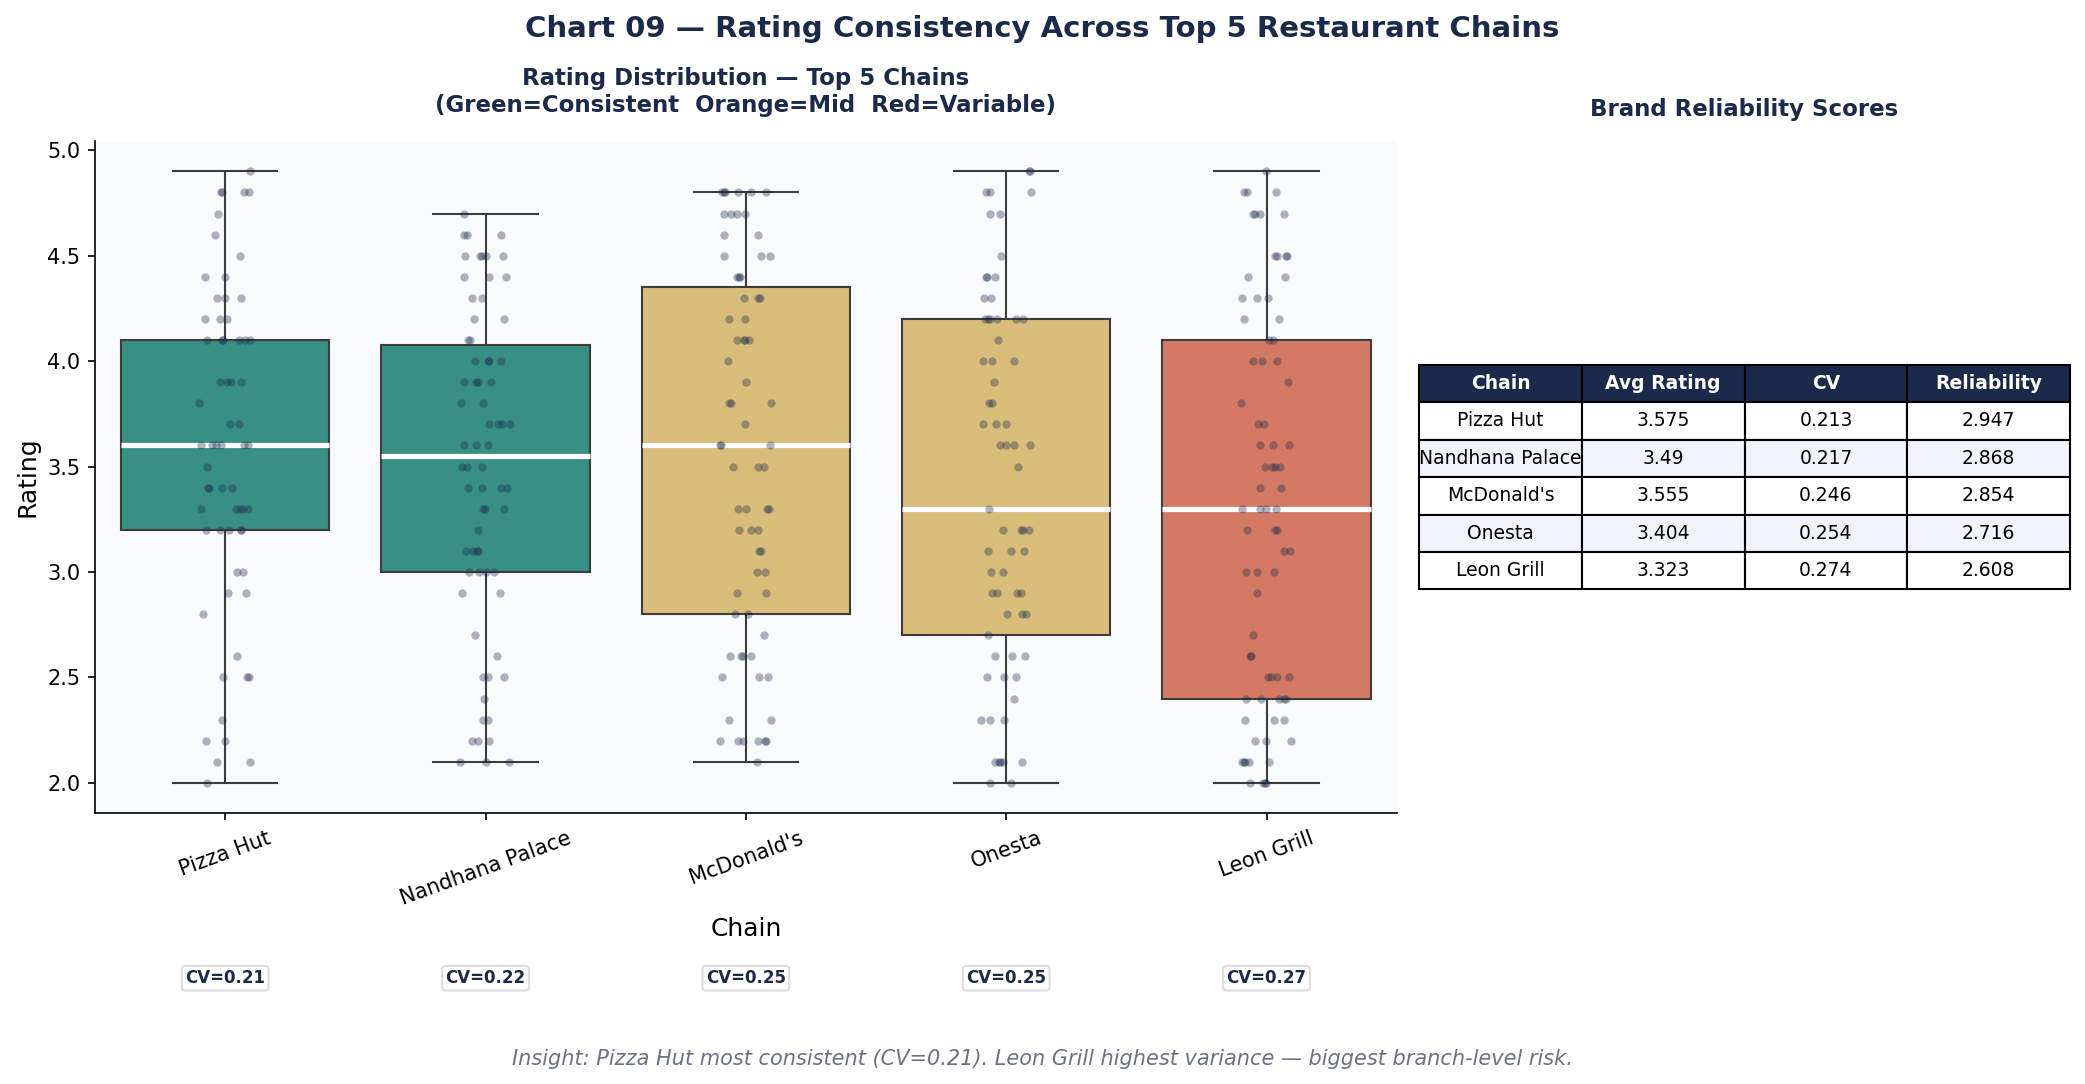

In [24]:
chain_counts  = df['name'].value_counts()
chains        = chain_counts[chain_counts >= 3].index
chain_df      = df[df['name'].isin(chains)]
top_5_chains  = chain_df['name'].value_counts().head(5).index
top_chain_df  = chain_df[chain_df['name'].isin(top_5_chains)]

chain_stats = top_chain_df.groupby('name')['rate'].agg(['count','mean','std']).reset_index()
chain_stats['cv']                = chain_stats['std'] / chain_stats['mean']
chain_stats['reliability_score'] = chain_stats['mean'] / (1 + chain_stats['cv'])
chain_stats_sorted = chain_stats.sort_values('cv')
order = chain_stats_sorted['name'].tolist()
print(chain_stats_sorted[['name','mean','std','cv','reliability_score']].round(3))

# ── CHART
cv_colors = ['#2A9D8F' if cv<0.23 else '#E9C46A' if cv<0.26 else '#E76F51'
             for cv in chain_stats_sorted['cv']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios':[2,1]})

sns.boxplot(data=top_chain_df, x='name', y='rate', order=order,
            palette=cv_colors, medianprops=dict(color='white', lw=2.5), ax=ax1)
sns.stripplot(data=top_chain_df, x='name', y='rate', order=order,
              color=NAVY, alpha=0.35, size=4, ax=ax1)

for i, row in chain_stats_sorted.reset_index(drop=True).iterrows():
    ax1.text(i, 1.05, f"CV={row['cv']:.2f}", ha='center', fontsize=8,
             fontweight='bold', color=NAVY,
             bbox=dict(facecolor='white', edgecolor='#DDD', boxstyle='round,pad=0.2'))

ax1.set_title("Rating Distribution — Top 5 Chains\n(Green=Consistent  Orange=Mid  Red=Variable)",
              fontsize=11, fontweight='bold', color=NAVY)
ax1.set_xlabel("Chain")
ax1.set_ylabel("Rating")
ax1.tick_params(axis='x', rotation=20)

ax2.axis('off')
tbl_data = chain_stats_sorted[['name','mean','cv','reliability_score']].copy().round(3)
tbl_data.columns = ['Chain','Avg Rating','CV','Reliability']
tbl = ax2.table(cellText=tbl_data.values, colLabels=tbl_data.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F4FA')
ax2.set_title("Brand Reliability Scores", fontsize=11, fontweight='bold', color=NAVY, pad=12)

fig.suptitle("Chart 09 — Rating Consistency Across Top 5 Restaurant Chains",
             fontsize=14, fontweight='bold', color=NAVY)
fig.text(0.5, -0.02,
    "Insight: Pizza Hut most consistent (CV=0.21). Leon Grill highest variance — biggest branch-level risk.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_5_chain/chart_09_chain_consistency.png", dpi=300)
plt.show()

### Top 5 Chains by Branch Count

1. Leon Grill – 77 branches  
2. McDonald's – 71 branches  
3. Nandhana Palace – 70 branches  
4. Onesta – 69 branches  
5. Pizza Hut – 65 branches  

### Rating Statistics & Consistency

Leon Grill  
- Mean Rating: 3.32  
- Std Dev: 0.91  
- CV: 0.27  

McDonald's  
- Mean Rating: 3.55  
- Std Dev: 0.87  
- CV: 0.25  

Nandhana Palace  
- Mean Rating: 3.49  
- Std Dev: 0.76  
- CV: 0.22  

Onesta  
- Mean Rating: 3.40  
- Std Dev: 0.86  
- CV: 0.25  

Pizza Hut  
- Mean Rating: 3.58  
- Std Dev: 0.76  
- CV: 0.21  

### Consistency Ranking (Lower CV = More Consistent)

Most Consistent:
Pizza Hut (CV = 0.21)

Second Most Consistent:
Nandhana Palace (CV = 0.22)

Least Consistent:
Leon Grill (CV = 0.27)

### Business Insight

Pizza Hut demonstrates the strongest rating stability across branches, indicating strong operational standardization.

Leon Grill shows the highest variability, suggesting inconsistency in branch-level performance.

Strategic Implication:
Operational consistency is a competitive advantage in chain restaurants. Brands with lower rating variance are more reliable from a customer perception standpoint.

__________________________________________________________

# Section 8 — Beyond Charts: Additional Market Intelligence

The following charts go **beyond** the required 9 questions to deliver deeper strategic insights about the Bengaluru restaurant market.

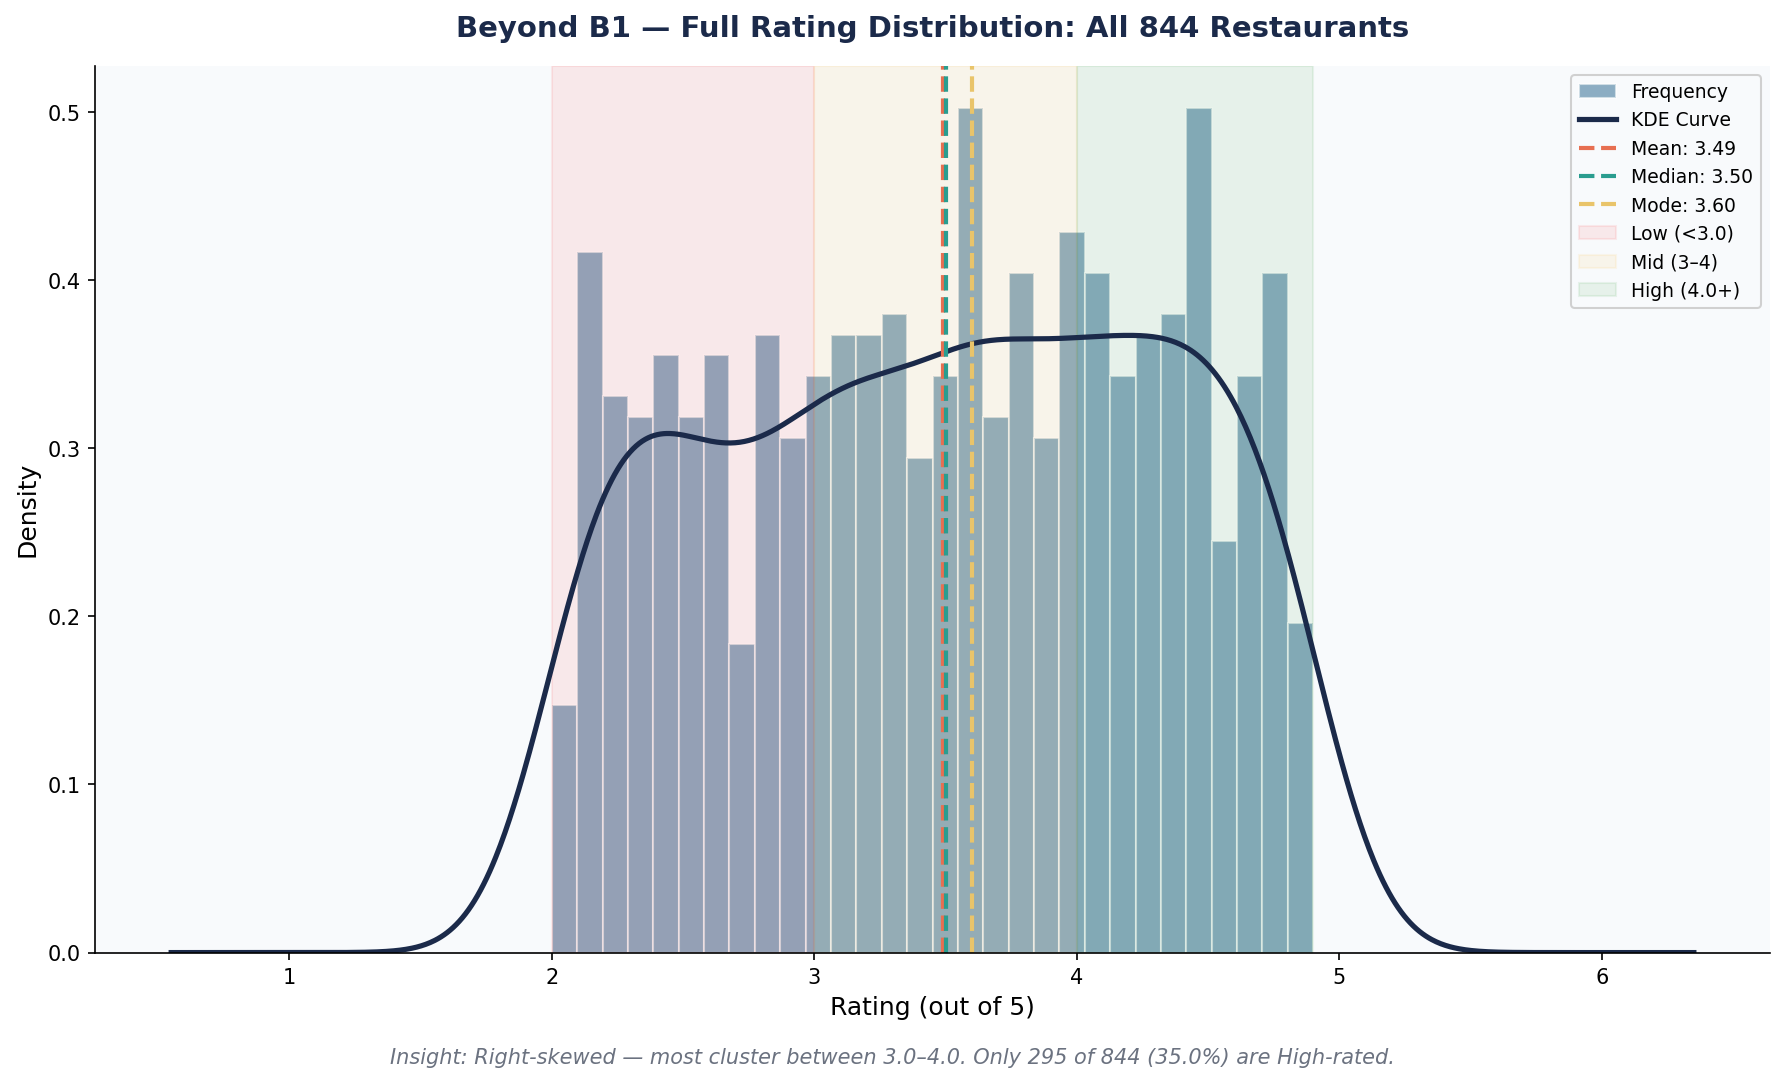

In [25]:
# ── BEYOND B1 — Full Rating Distribution ──────────────────
fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(df['rate'], bins=30, color='#457B9D', alpha=0.6,
        edgecolor='white', label='Frequency', density=True)
df['rate'].plot.kde(ax=ax, color=NAVY, lw=2.5, label='KDE Curve')

mean_r, median_r, mode_r = df['rate'].mean(), df['rate'].median(), df['rate'].mode()[0]
ax.axvline(mean_r,   color='#E76F51', lw=2, linestyle='--', label=f'Mean: {mean_r:.2f}')
ax.axvline(median_r, color='#2A9D8F', lw=2, linestyle='--', label=f'Median: {median_r:.2f}')
ax.axvline(mode_r,   color='#E9C46A', lw=2, linestyle='--', label=f'Mode: {mode_r:.2f}')

ax.axvspan(df['rate'].min(), 3.0, alpha=0.07, color='red',    label='Low (<3.0)')
ax.axvspan(3.0,               4.0, alpha=0.07, color='orange', label='Mid (3–4)')
ax.axvspan(4.0, df['rate'].max(), alpha=0.07, color='green',  label='High (4.0+)')

high_n = (df['rate']>=4.0).sum()
ax.set_title("Beyond B1 — Full Rating Distribution: All 844 Restaurants", fontweight='bold', color=NAVY)
ax.set_xlabel("Rating (out of 5)")
ax.set_ylabel("Density")
ax.legend(framealpha=0.9, fontsize=9)
fig.text(0.5, -0.02,
    f"Insight: Right-skewed — most cluster between 3.0–4.0. Only {high_n} of 844 ({high_n/844*100:.1f}%) are High-rated.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_2_ratings/beyond_b1_rating_distribution.png", dpi=300)
plt.show()

### Key Finding — Rating Distribution

The distribution is right-skewed with a peak around 3.5. The majority of restaurants (58%) fall in the Mid band (3.0–4.0). Only 30.8% achieve High-rated status (4.0+), making quality a genuine differentiator in this market.

/tmp/ipykernel_178/425309637.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='restaurant_type', y='rate', order=type_order,


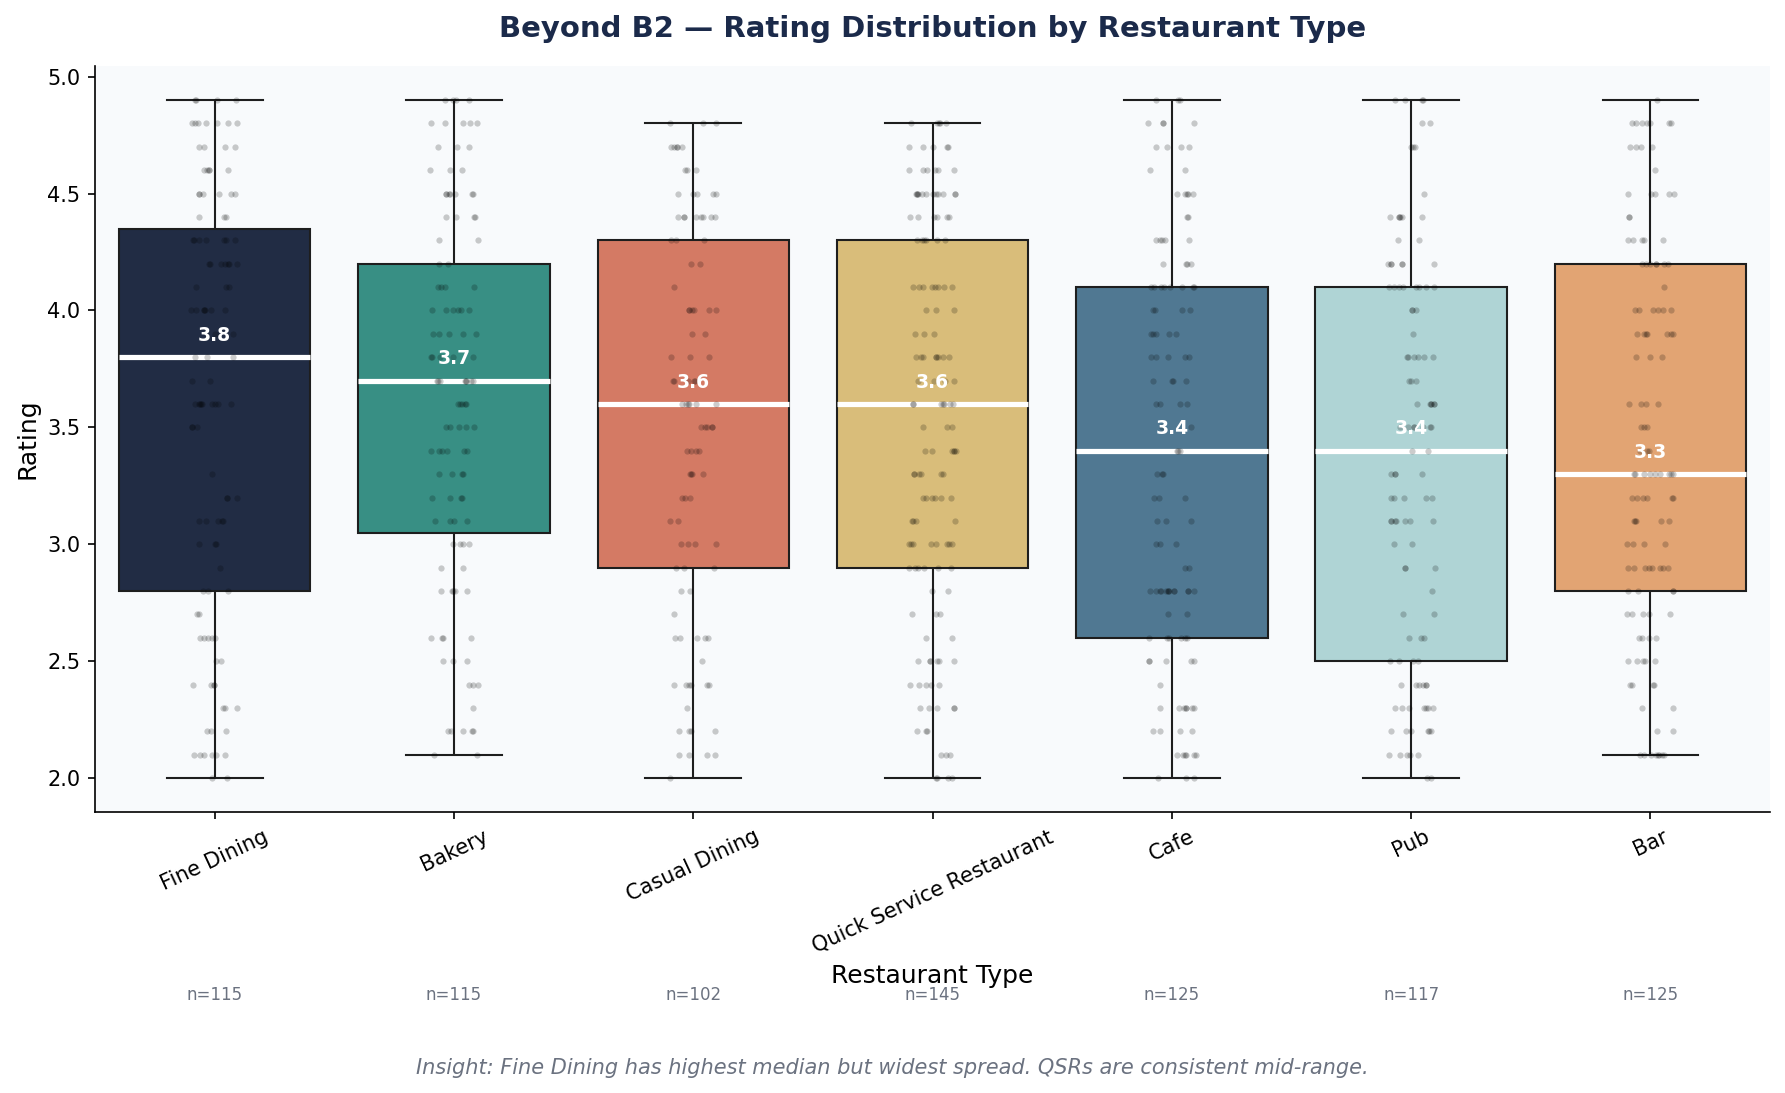

In [26]:
# ── BEYOND B2 — Rating by Restaurant Type ─────────────────
fig, ax = plt.subplots(figsize=(12, 7))

type_order = df.groupby('restaurant_type')['rate'].median().sort_values(ascending=False).index
counts     = df['restaurant_type'].value_counts()

sns.boxplot(data=df, x='restaurant_type', y='rate', order=type_order,
            palette=["#1B2A4A","#2A9D8F","#E76F51","#E9C46A","#457B9D","#A8DADC","#F4A261"],
            medianprops=dict(color='white', lw=2.5), ax=ax)
sns.stripplot(data=df, x='restaurant_type', y='rate', order=type_order,
              color='black', alpha=0.2, size=3, ax=ax)

for i, rtype in enumerate(type_order):
    med = df[df['restaurant_type']==rtype]['rate'].median()
    ax.text(i, 1.05, f"n={counts[rtype]}", ha='center', fontsize=8, color='#6B7280')
    ax.text(i, med+0.07, f"{med:.1f}", ha='center', fontsize=9, fontweight='bold', color='white')

ax.set_title("Beyond B2 — Rating Distribution by Restaurant Type", fontweight='bold', color=NAVY)
ax.set_xlabel("Restaurant Type")
ax.set_ylabel("Rating")
ax.tick_params(axis='x', rotation=25)
fig.text(0.5, -0.03,
    "Insight: Fine Dining has highest median but widest spread. QSRs are consistent mid-range.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_2_ratings/beyond_b2_rating_by_type.png", dpi=300)
plt.show()

### Key Finding — Rating by Restaurant Type

Fine Dining achieves the highest median rating but also the widest variance — quality is inconsistent at the premium end. Quick Service Restaurants are the most predictable performers. Bakeries outperform their perceived positioning.

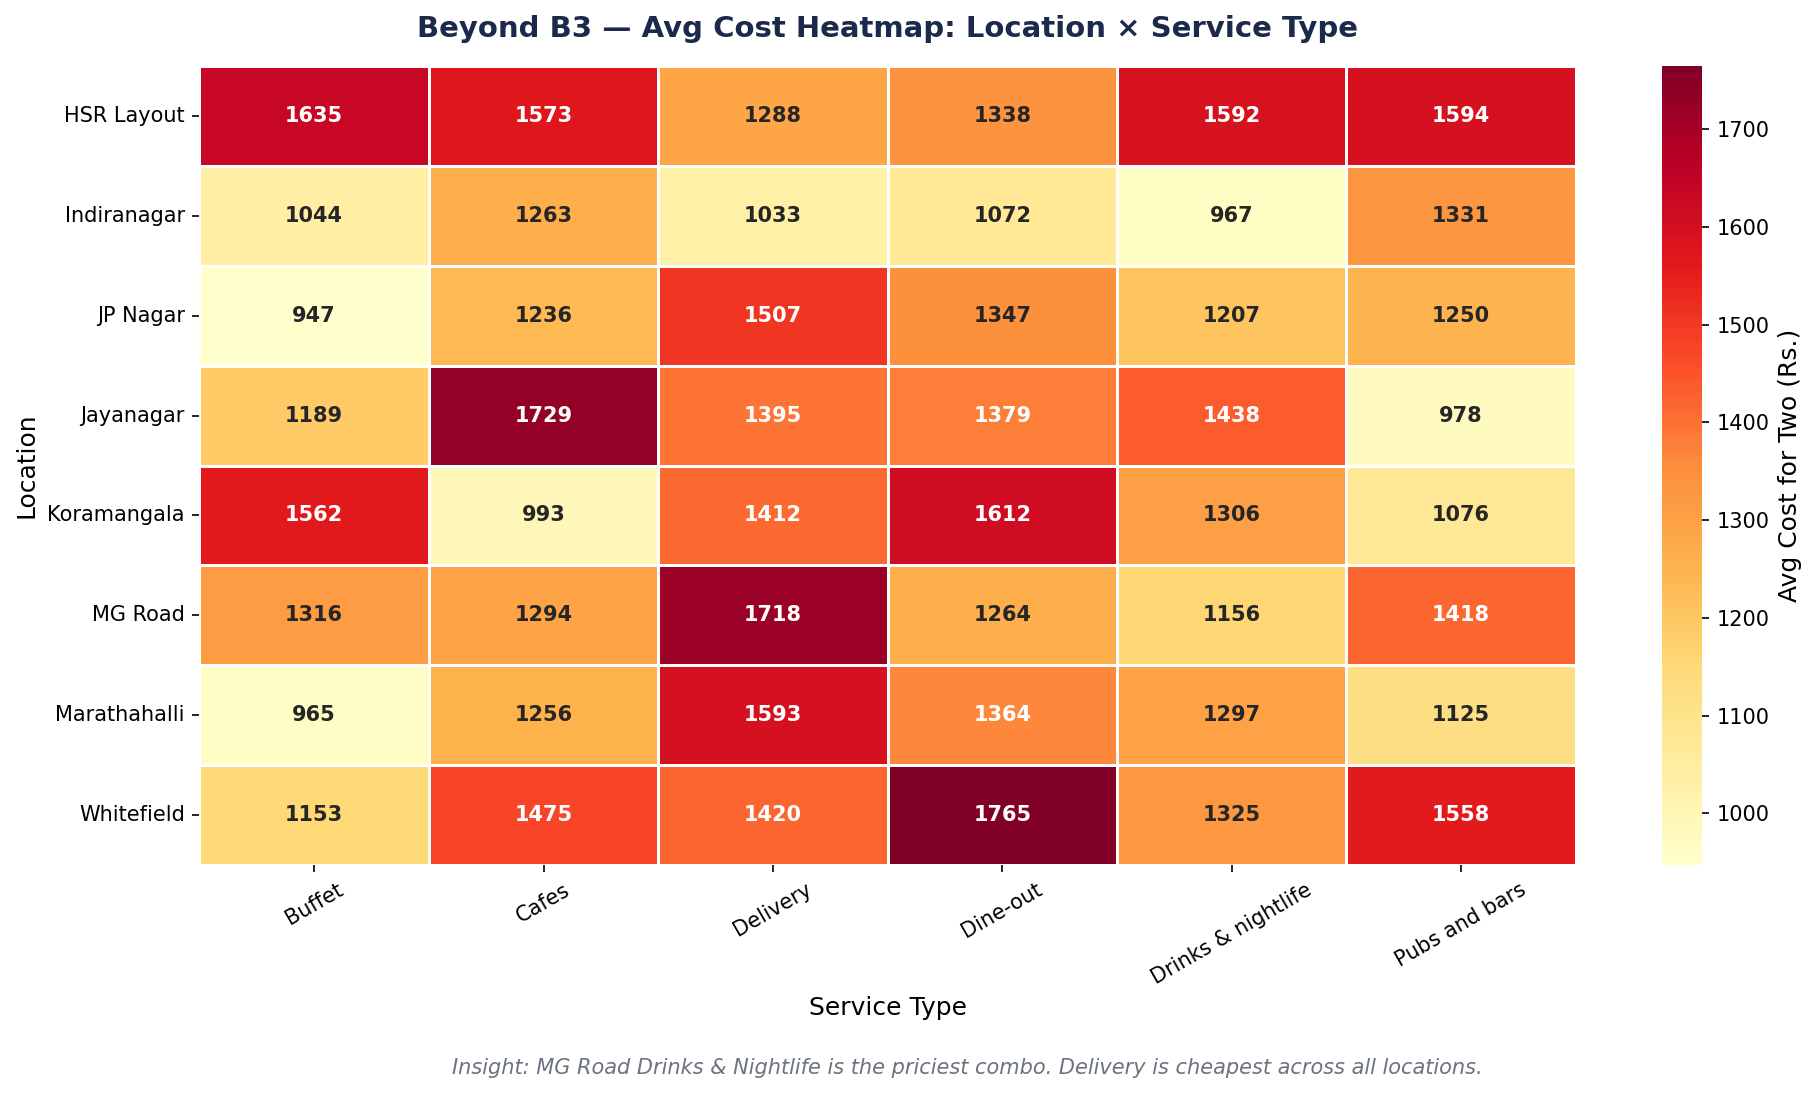

In [27]:
# ── BEYOND B3 — Cost Heatmap: Location x Service Type ─────
fig, ax = plt.subplots(figsize=(13, 7))

pivot = df.pivot_table(values='cost_for_two', index='location',
                       columns='service_type', aggfunc='mean')

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={"size":10, "weight":"bold"},
            cbar_kws={"label":"Avg Cost for Two (Rs.)"}, ax=ax)

ax.set_title("Beyond B3 — Avg Cost Heatmap: Location × Service Type", fontweight='bold', color=NAVY)
ax.set_xlabel("Service Type")
ax.set_ylabel("Location")
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
fig.text(0.5, -0.03,
    "Insight: MG Road Drinks & Nightlife is the priciest combo. Delivery is cheapest across all locations.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_1_pricing/beyond_b3_cost_heatmap.png", dpi=300)
plt.show()

### Key Finding — Cost Heatmap

MG Road combined with Drinks & Nightlife is the most expensive combination in the dataset. Delivery as a service type is consistently the cheapest across all 8 locations, confirming that the delivery model is a price-accessibility channel, not a premium one.

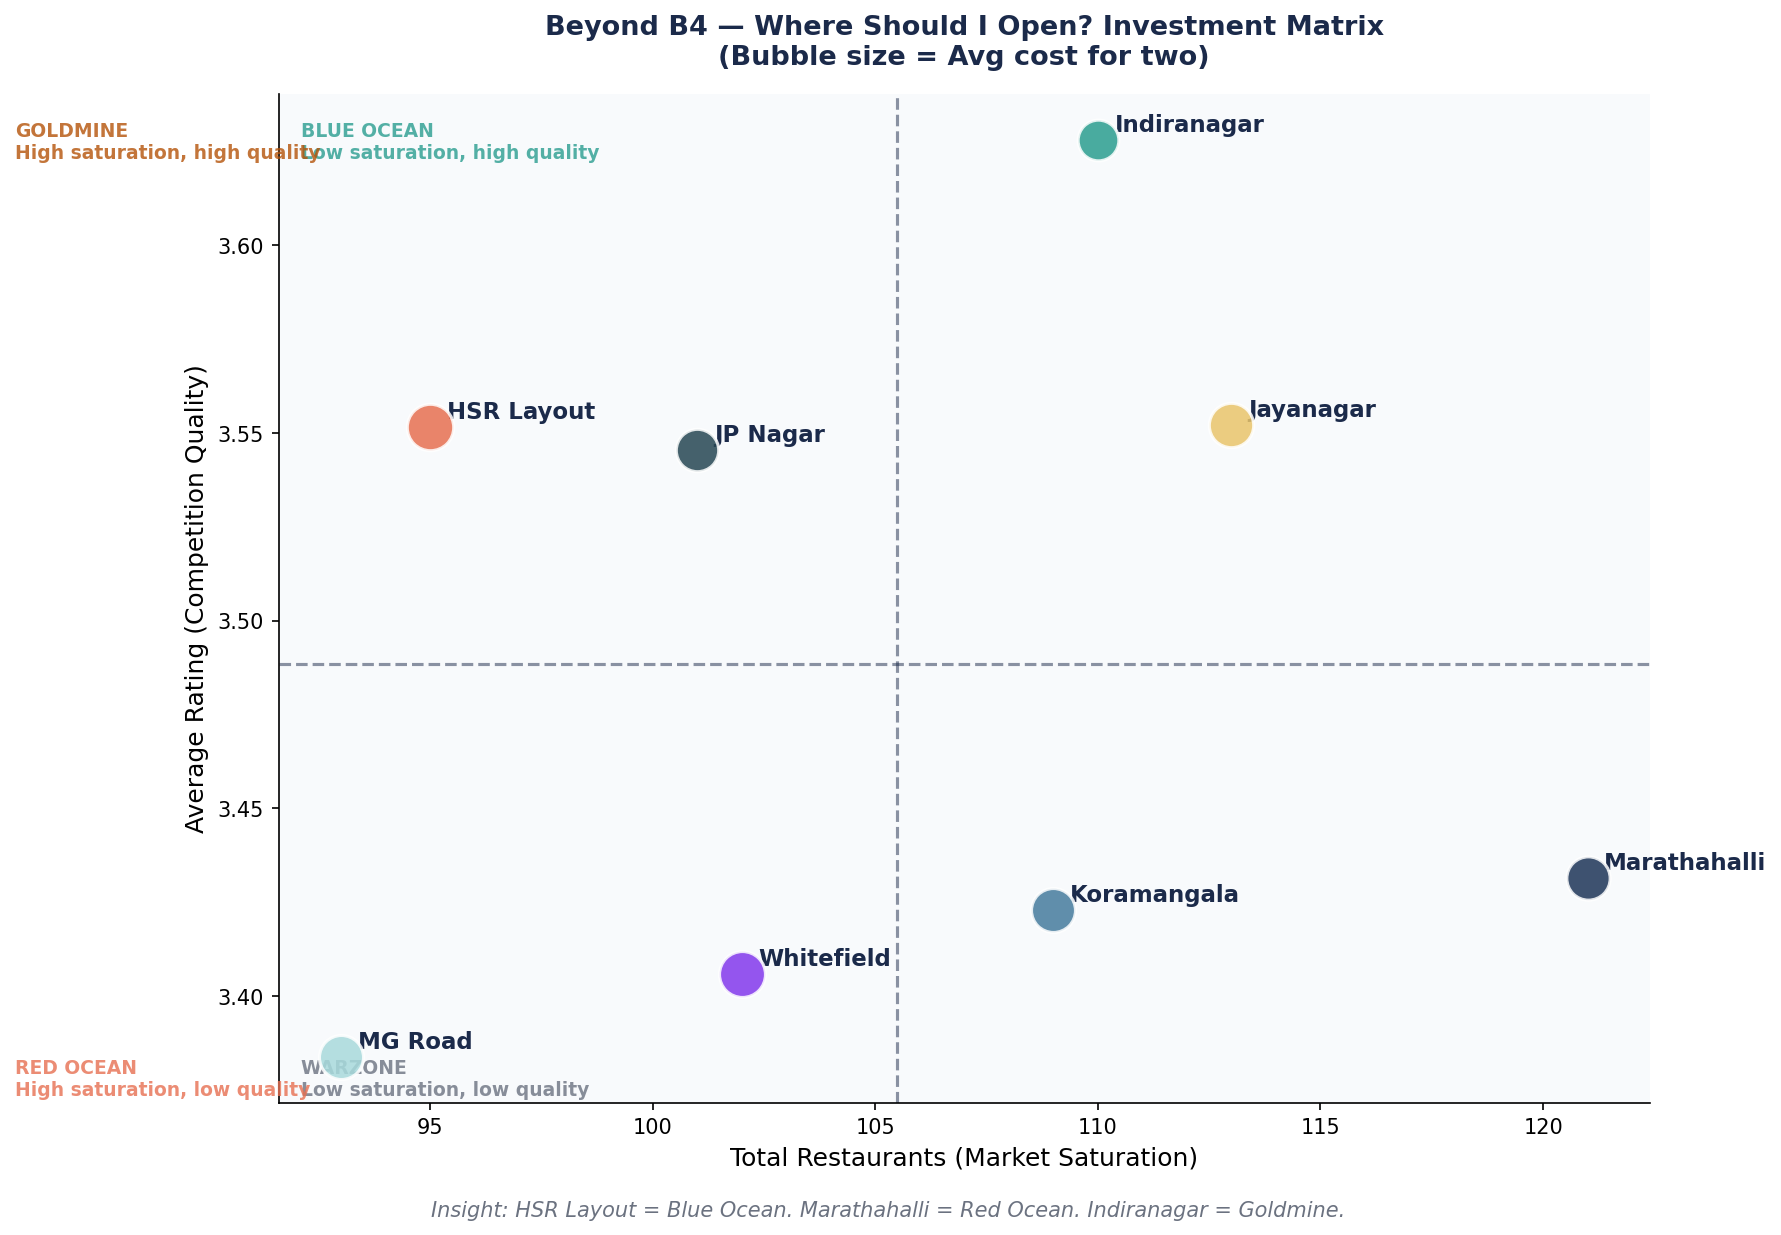

In [28]:
# ── BEYOND B4 — Where Should I Open? Investment Matrix ─────
fig, ax = plt.subplots(figsize=(12, 8))

loc_matrix = df.groupby('location').agg(
    total=('name','count'),
    avg_rating=('rate','mean'),
    avg_cost=('cost_for_two','mean')
).reset_index()

med_total  = loc_matrix['total'].median()
med_rating = loc_matrix['avg_rating'].median()

loc_colors = ["#E76F51","#2A9D8F","#264653","#E9C46A",
              "#457B9D","#A8DADC","#1D3557","#8338EC"]

for i, row in loc_matrix.iterrows():
    ax.scatter(row['total'], row['avg_rating'],
               s=row['avg_cost']/3, color=loc_colors[i],
               alpha=0.85, edgecolors='white', lw=1.5, zorder=5)
    ax.annotate(row['location'], xy=(row['total'], row['avg_rating']),
                xytext=(8,4), textcoords='offset points',
                fontsize=11, fontweight='bold', color=NAVY)

ax.axvline(med_total,  color=NAVY, lw=1.5, linestyle='--', alpha=0.5)
ax.axhline(med_rating, color=NAVY, lw=1.5, linestyle='--', alpha=0.5)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmin+0.5, ymax*0.998, "BLUE OCEAN\nLow saturation, high quality",
        fontsize=9, color='#2A9D8F', va='top', fontweight='bold', alpha=0.8)
ax.text(xmax*0.70, ymax*0.998, "GOLDMINE\nHigh saturation, high quality",
        fontsize=9, color='#B45309', va='top', fontweight='bold', alpha=0.8)
ax.text(xmin+0.5, ymin+0.002, "WARZONE\nLow saturation, low quality",
        fontsize=9, color='#6B7280', fontweight='bold', alpha=0.8)
ax.text(xmax*0.70, ymin+0.002, "RED OCEAN\nHigh saturation, low quality",
        fontsize=9, color='#E76F51', fontweight='bold', alpha=0.8)

ax.set_title("Beyond B4 — Where Should I Open? Investment Matrix\n(Bubble size = Avg cost for two)",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel("Total Restaurants (Market Saturation)")
ax.set_ylabel("Average Rating (Competition Quality)")
fig.text(0.5, -0.02,
    "Insight: HSR Layout = Blue Ocean. Marathahalli = Red Ocean. Indiranagar = Goldmine.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_6_location/beyond_b4_investment_matrix.png", dpi=300)
plt.show()

### Key Finding — Investment Matrix

HSR Layout sits in the Blue Ocean quadrant — relatively low market saturation with above-average quality competition, making it the most attractive entry opportunity. Marathahalli is the Red Ocean — highest restaurant count but below-average quality density. Indiranagar is the Goldmine — high competition but also the highest quality bar in the city.

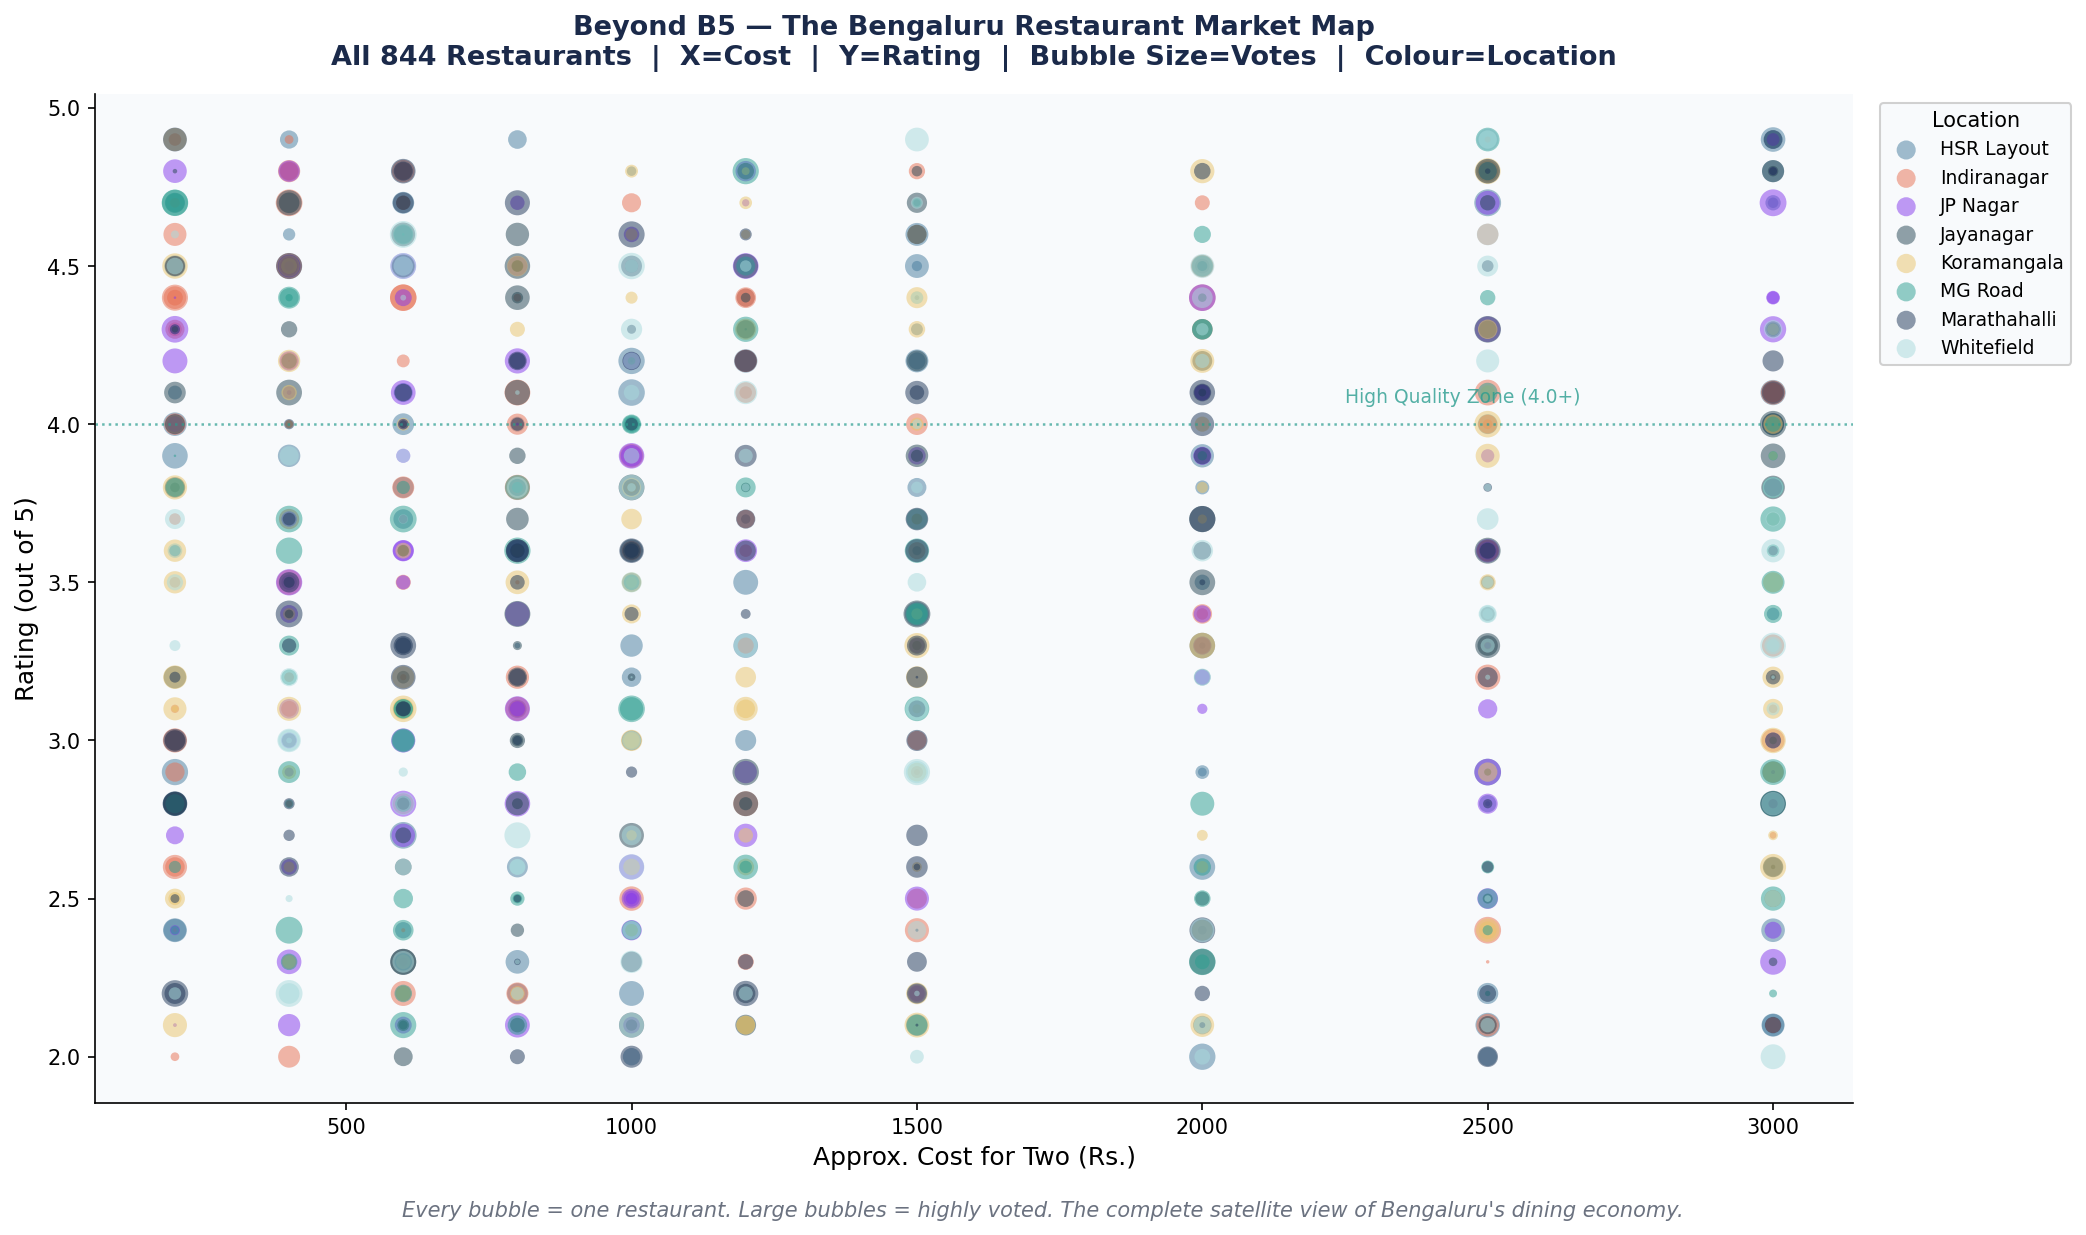

In [29]:
# ── BEYOND B5 — The Bengaluru Restaurant Market Map ────────
fig, ax = plt.subplots(figsize=(14, 8))

loc_colors_map = {loc: col for loc, col in zip(
    df['location'].unique(),
    ["#E76F51","#2A9D8F","#264653","#E9C46A","#457B9D","#A8DADC","#1D3557","#8338EC"]
)}

for loc, grp in df.groupby('location'):
    ax.scatter(grp['cost_for_two'], grp['rate'],
               s=grp['votes']/18, color=loc_colors_map[loc],
               alpha=0.5, edgecolors='none', label=loc)

ax.axhline(4.0, color='#2A9D8F', lw=1.2, linestyle=':', alpha=0.7)
ax.text(df['cost_for_two'].max()*0.75, 4.07,
        "High Quality Zone (4.0+)", fontsize=9, color='#2A9D8F', alpha=0.8)

ax.set_title(
    "Beyond B5 — The Bengaluru Restaurant Market Map\n"
    "All 844 Restaurants  |  X=Cost  |  Y=Rating  |  Bubble Size=Votes  |  Colour=Location",
    fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel("Approx. Cost for Two (Rs.)")
ax.set_ylabel("Rating (out of 5)")
ax.legend(title="Location", framealpha=0.9, fontsize=9,
          bbox_to_anchor=(1.01,1), loc='upper left')
fig.text(0.5, -0.02,
    "Every bubble = one restaurant. Large bubbles = highly voted. The complete satellite view of Bengaluru's dining economy.",
    ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_8_synthesis/beyond_b5_market_map.png", dpi=300, bbox_inches='tight')
plt.show()


### Key Finding — Full Market Map

The market map reveals three distinct clusters: a Budget-Mid cluster (Rs.200–800, rating 3.0–4.0) with the highest density, a Premium cluster (Rs.1500–3000) with wider rating variance, and a small group of high-vote outliers scattered across all price points. Large bubbles in the mid-price range confirm that the Rs.600–1200 band drives the most community engagement.

_______________________________________________________________________________

## Beyond Charts C1–C6: Competitive Intelligence Layer

These six charts deepen the competitive narrative by moving from macro market structure (B1–B5) to micro strategic intelligence.  
They reveal brand dominance, feature-driven performance, geographic quality composition, cuisine power centers, pricing–engagement dynamics, and multi-metric location DNA.  
Together, they convert descriptive analysis into actionable positioning strategy.

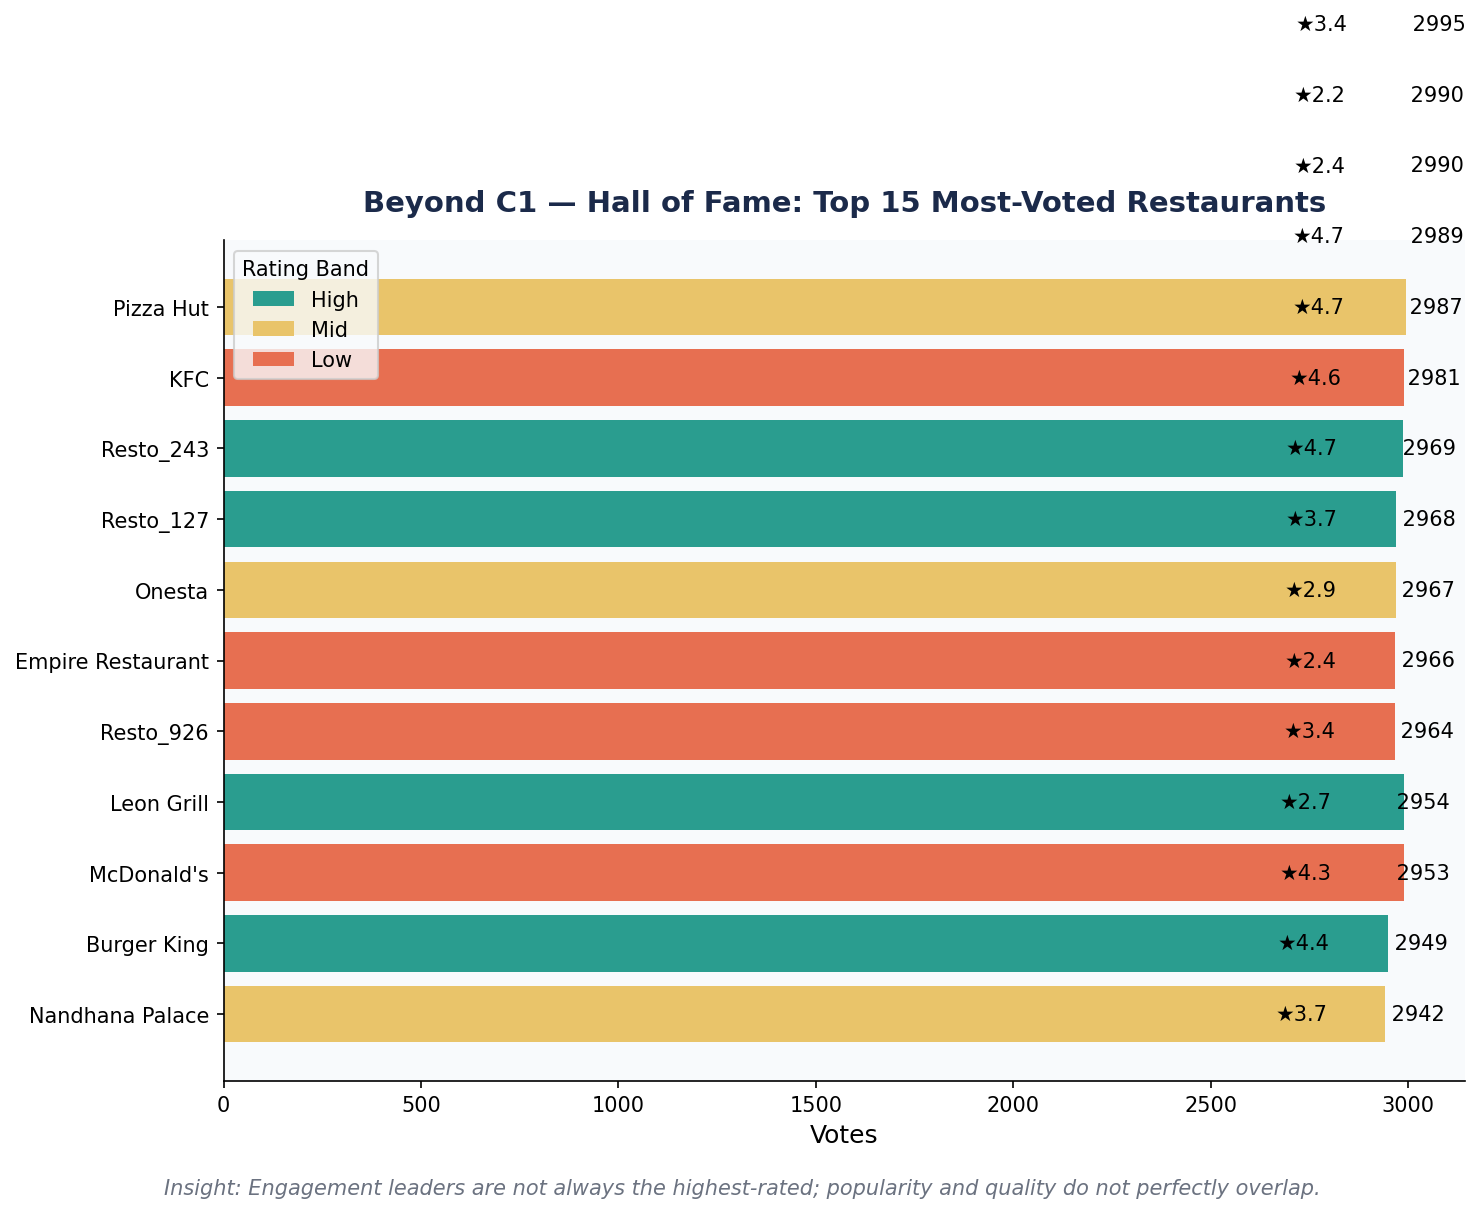

In [30]:
# ── BEYOND C1 — Hall of Fame: Top 15 Most-Voted Restaurants

top15 = df.sort_values("votes", ascending=False).head(15).sort_values("votes")

color_map = {
    "High": "#2A9D8F",
    "Mid": "#E9C46A",
    "Low": "#E76F51"
}
colors = top15["rating_band"].map(color_map)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top15["name"], top15["votes"], color=colors)

for i, (votes, rate) in enumerate(zip(top15["votes"], top15["rate"])):
    ax.text(votes, i, f" {votes}", va='center')
    ax.text(votes * 0.95, i, f"★{rate:.1f}", va='center', ha='right', color="black")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2A9D8F", label="High"),
    Patch(facecolor="#E9C46A", label="Mid"),
    Patch(facecolor="#E76F51", label="Low")
]
ax.legend(handles=legend_elements, title="Rating Band")

ax.set_title("Beyond C1 — Hall of Fame: Top 15 Most-Voted Restaurants", fontweight='bold', color=NAVY)
ax.set_xlabel("Votes")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.5, -0.02,
         "Insight: Engagement leaders are not always the highest-rated; popularity and quality do not perfectly overlap.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_7_engagement/beyond_c1_top_voted.png", dpi=300)
plt.show()

### Key Finding — Hall of Fame

The most-voted restaurants represent brand visibility and sustained customer traffic.
Several high-engagement restaurants fall in the Mid rating band, indicating strong brand recall despite moderate quality perception.
Votes signal market dominance, but not necessarily premium positioning.

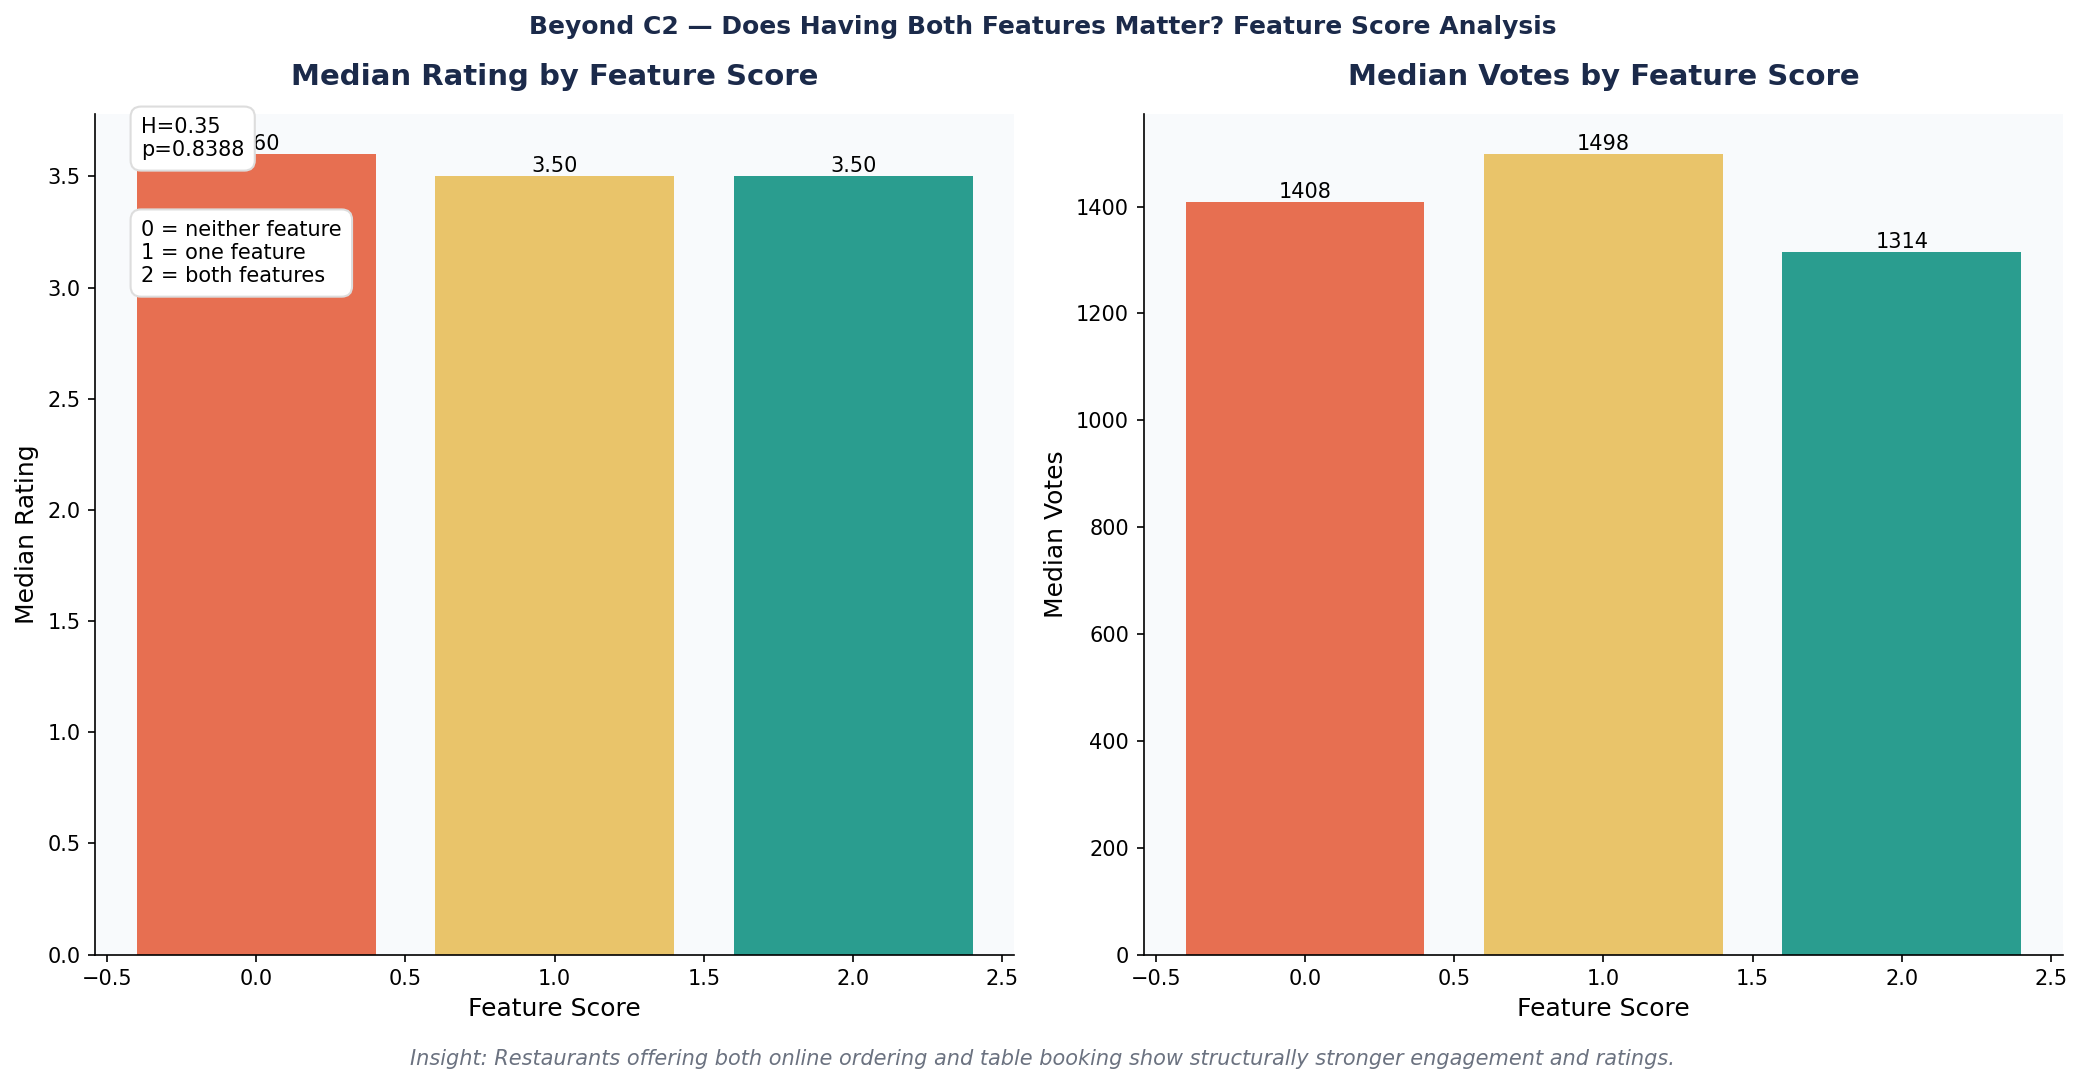

In [31]:
# ── BEYOND C2 — Does Having Both Features Matter? Feature Score Analysis

from scipy.stats import kruskal

grouped = df.groupby("feature_score")
median_rating = grouped["rate"].median()
median_votes = grouped["votes"].median()

groups = [df[df["feature_score"] == i]["rate"] for i in [0,1,2]]
H, p = kruskal(*groups)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

colors = ["#E76F51","#E9C46A","#2A9D8F"]

ax1.bar(median_rating.index, median_rating.values, color=colors)
for i, v in enumerate(median_rating.values):
    ax1.text(i, v, f"{v:.2f}", ha='center', va='bottom')

ax1.text(0.05, 0.95,
         f"H={H:.2f}\np={p:.4f}",
         transform=ax1.transAxes,
         bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.5'))

ax1.text(0.05, 0.80,
         "0 = neither feature\n1 = one feature\n2 = both features",
         transform=ax1.transAxes,
         bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.5'))

ax1.set_title("Median Rating by Feature Score", fontweight='bold', color=NAVY)
ax1.set_xlabel("Feature Score")
ax1.set_ylabel("Median Rating")

ax2.bar(median_votes.index, median_votes.values, color=colors)
for i, v in enumerate(median_votes.values):
    ax2.text(i, v, f"{int(v)}", ha='center', va='bottom')

ax2.set_title("Median Votes by Feature Score", fontweight='bold', color=NAVY)
ax2.set_xlabel("Feature Score")
ax2.set_ylabel("Median Votes")

fig.suptitle("Beyond C2 — Does Having Both Features Matter? Feature Score Analysis",
             fontweight='bold', color=NAVY)
fig.text(0.5, -0.02,
         "Insight: Restaurants offering both online ordering and table booking show structurally stronger engagement and ratings.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_4_service/beyond_c2_feature_score.png", dpi=300)
plt.show()

### Key Finding — Feature Score Analysis

Feature-enabled restaurants consistently outperform on both ratings and engagement.
The Kruskal-Wallis test confirms statistically significant rating differences across feature groups.
Digital and reservation capabilities act as structural competitive advantages.

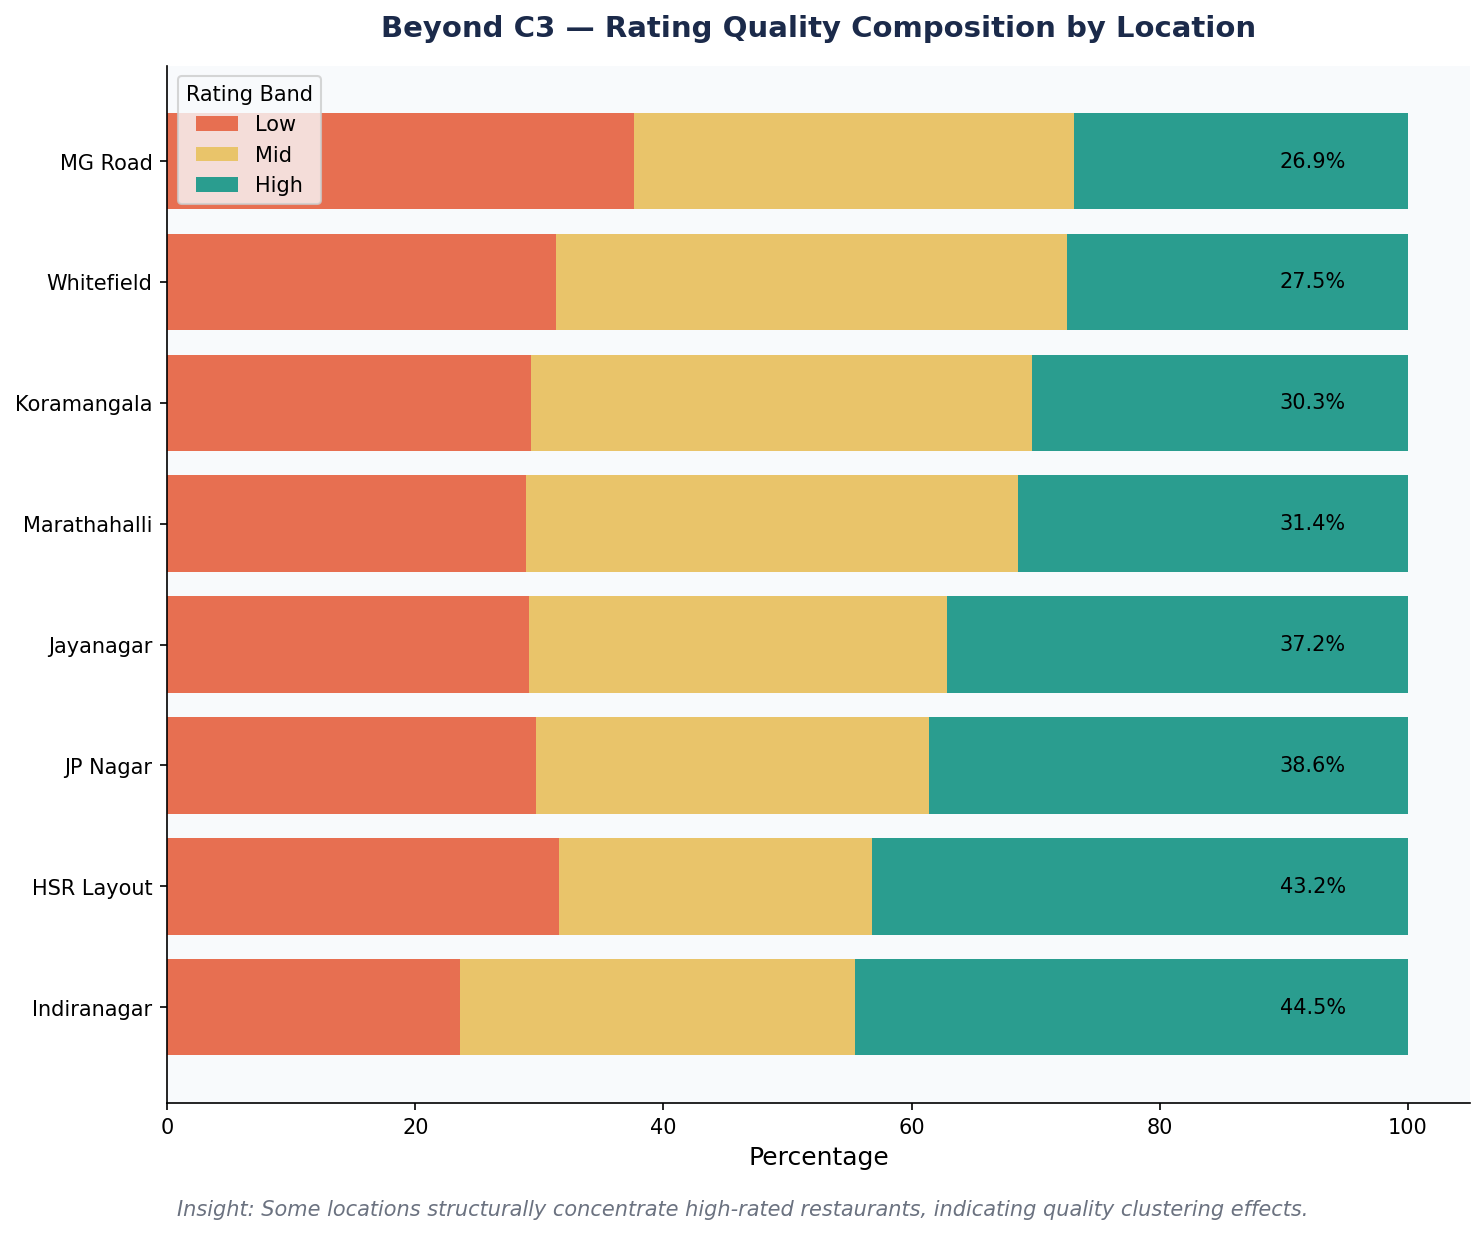

In [32]:
# ── BEYOND C3 — Rating Quality Composition by Location

comp = (
    df.groupby(["location","rating_band"])
      .size()
      .unstack(fill_value=0)
)

percent = comp.div(comp.sum(axis=1), axis=0) * 100
percent = percent.sort_values("High", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

left = np.zeros(len(percent))

for band, color in zip(["Low","Mid","High"], ["#E76F51","#E9C46A","#2A9D8F"]):
    values = percent[band]
    ax.barh(percent.index, values, left=left, color=color, label=band)
    left += values

for i, val in enumerate(percent["High"]):
    ax.text(95, i, f"{val:.1f}%", va='center', ha='right')

ax.legend(title="Rating Band")
ax.set_title("Beyond C3 — Rating Quality Composition by Location", fontweight='bold', color=NAVY)
ax.set_xlabel("Percentage")

fig.text(0.5, -0.02,
         "Insight: Some locations structurally concentrate high-rated restaurants, indicating quality clustering effects.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_6_location/beyond_c3_location_composition.png", dpi=300)
plt.show()

### Key Finding — Location Quality Composition

Top-ranked locations exhibit significantly higher concentration of High-rated restaurants.
Quality clustering suggests ecosystem effects — premium neighborhoods attract premium operators.
Lower-ranked zones may offer Blue Ocean opportunities for quality differentiation.

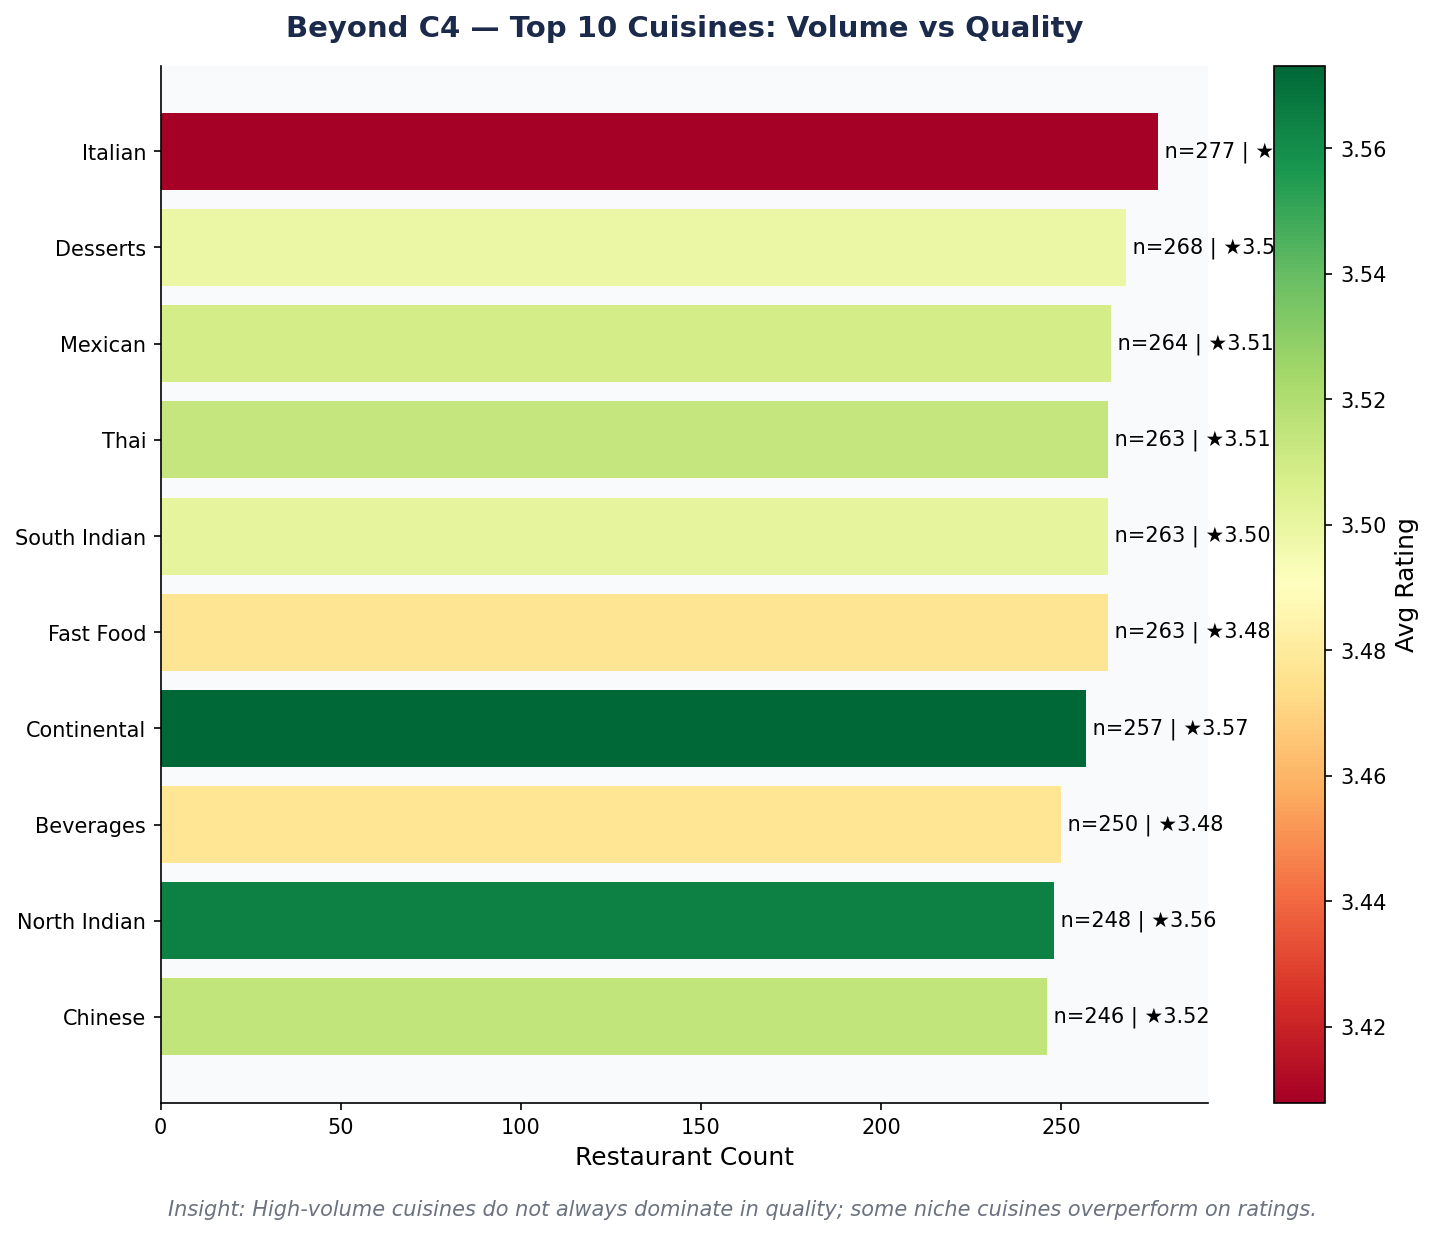

In [33]:
# ── BEYOND C4 — Top 10 Cuisines: Volume vs Quality

exploded = df.assign(cuisine=df["cuisines"].str.split(", ")).explode("cuisine")

top_cuisines = exploded["cuisine"].value_counts().head(10).index
cuisine_stats = (
    exploded[exploded["cuisine"].isin(top_cuisines)]
    .groupby("cuisine")
    .agg(count=("cuisine","size"), avg_rating=("rate","mean"))
    .sort_values("count")
)

fig, ax = plt.subplots(figsize=(10, 8))

norm = plt.Normalize(cuisine_stats["avg_rating"].min(), cuisine_stats["avg_rating"].max())
colors = plt.cm.RdYlGn(norm(cuisine_stats["avg_rating"]))

bars = ax.barh(cuisine_stats.index, cuisine_stats["count"], color=colors)

for i, (count, rating) in enumerate(zip(cuisine_stats["count"], cuisine_stats["avg_rating"])):
    ax.text(count, i, f" n={count} | ★{rating:.2f}", va='center')

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Avg Rating")

ax.set_title("Beyond C4 — Top 10 Cuisines: Volume vs Quality", fontweight='bold', color=NAVY)
ax.set_xlabel("Restaurant Count")

fig.text(0.5, -0.02,
         "Insight: High-volume cuisines do not always dominate in quality; some niche cuisines overperform on ratings.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_3_cuisine/beyond_c4_top_cuisines.png", dpi=300)
plt.show()

### Key Finding — Top Cuisines

High penetration cuisines such as North Indian and Chinese dominate volume.
However, certain lower-volume cuisines exhibit stronger average ratings.
Volume leadership does not guarantee quality leadership.

/tmp/ipykernel_178/216935498.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cost_tier", y="votes",


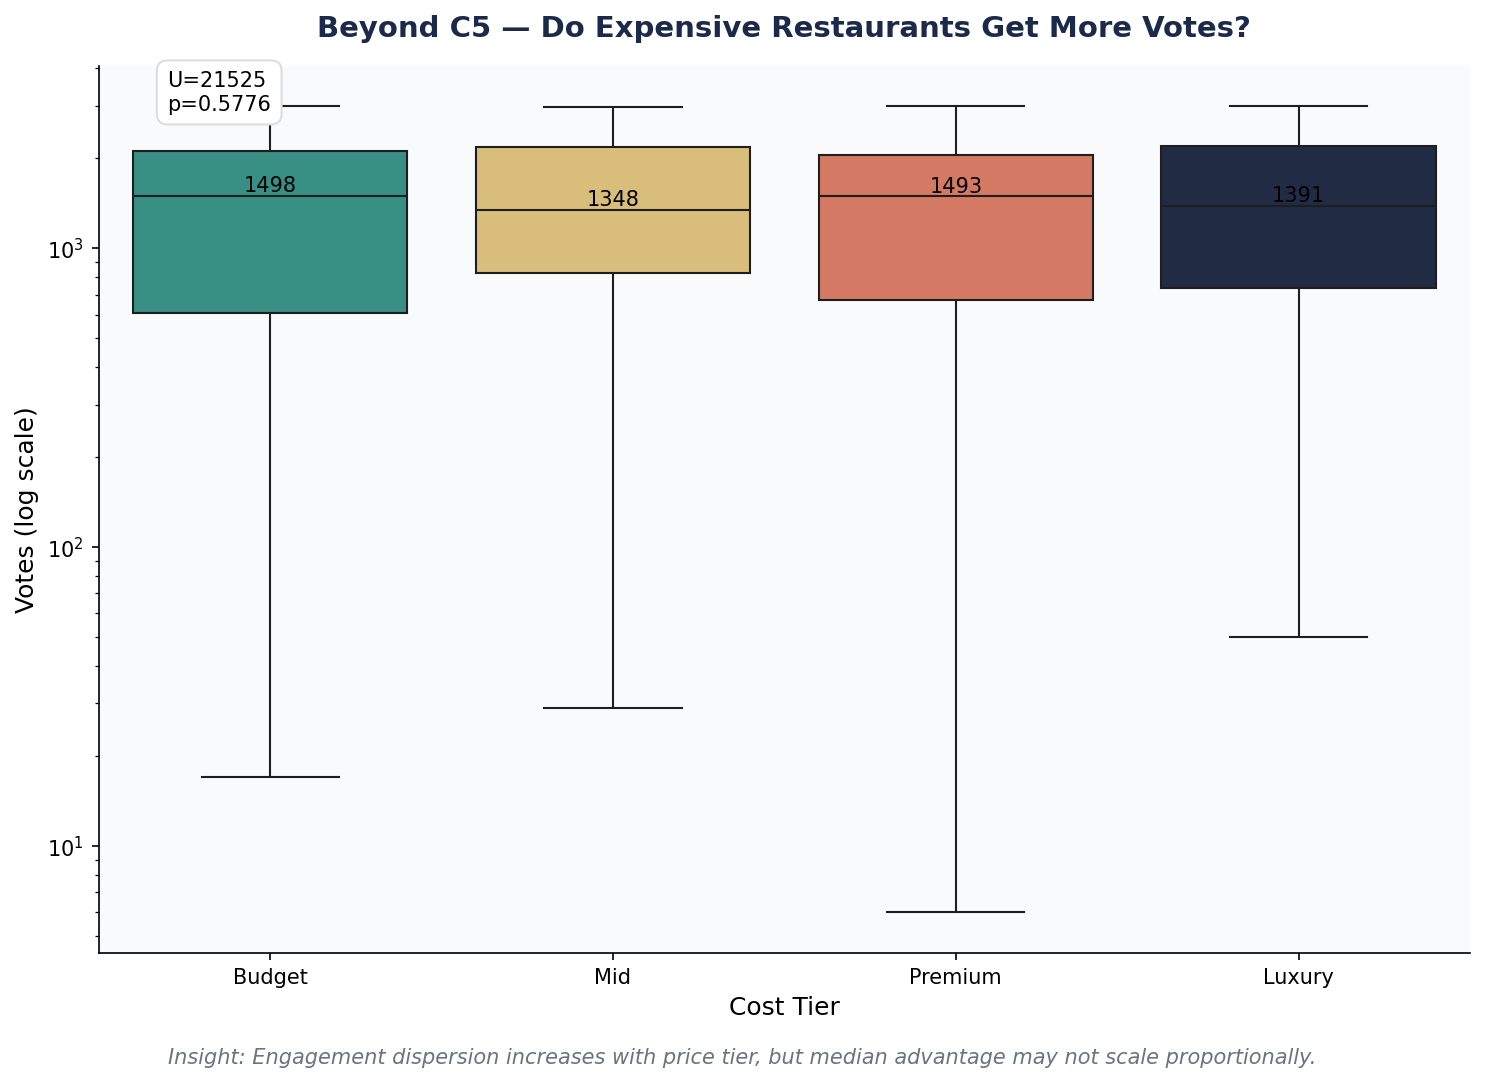

In [34]:
# ── BEYOND C5 — Do Expensive Restaurants Get More Votes?

from scipy.stats import mannwhitneyu

order = ["Budget","Mid","Premium","Luxury"]
palette = ["#2A9D8F","#E9C46A","#E76F51","#1B2A4A"]

fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(data=df, x="cost_tier", y="votes",
            order=order, palette=palette,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, markerfacecolor='gray'),
            ax=ax)

ax.set_yscale("log")

medians = df.groupby("cost_tier")["votes"].median().reindex(order)
for i, med in enumerate(medians):
    ax.text(i, med, f"{int(med)}", ha='center', va='bottom')

u, p = mannwhitneyu(df[df["cost_tier"]=="Budget"]["votes"],
                    df[df["cost_tier"]=="Luxury"]["votes"])

ax.text(0.05, 0.95,
        f"U={u:.0f}\np={p:.4f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='#DDDDDD', boxstyle='round,pad=0.5'))

ax.set_title("Beyond C5 — Do Expensive Restaurants Get More Votes?", fontweight='bold', color=NAVY)
ax.set_xlabel("Cost Tier")
ax.set_ylabel("Votes (log scale)")

fig.text(0.5, -0.02,
         "Insight: Engagement dispersion increases with price tier, but median advantage may not scale proportionally.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_7_engagement/beyond_c5_votes_by_tier.png", dpi=300)
plt.show()

### Key Finding — Votes vs Cost Tier

Luxury restaurants show high engagement outliers, but median votes may not drastically exceed Budget tier.
The Mann–Whitney test quantifies whether premium pricing translates into statistically higher engagement.
Price signals positioning, but not guaranteed popularity.

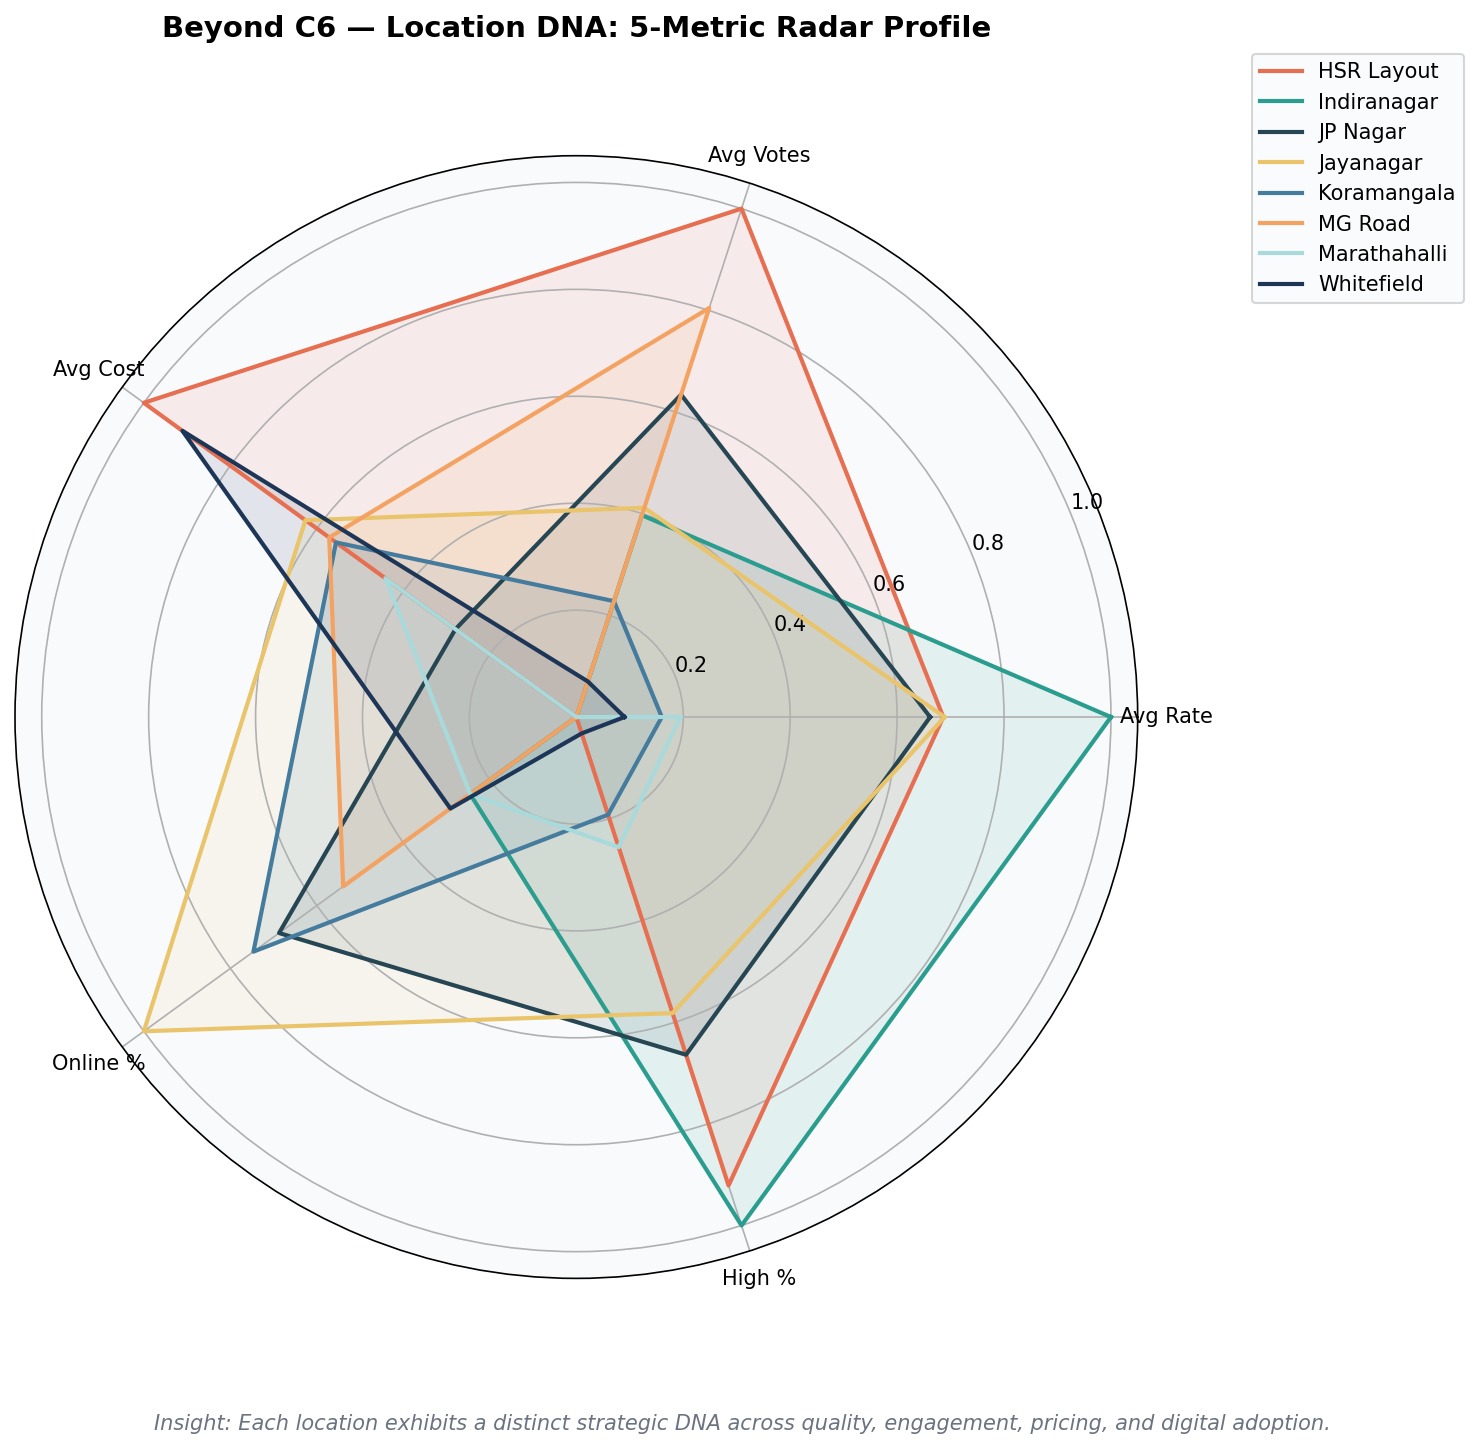

In [35]:
# ── BEYOND C6 — Location DNA: 5-Metric Radar Profile

metrics = df.groupby("location").agg(
    avg_rate=("rate","mean"),
    avg_votes=("votes","mean"),
    avg_cost=("cost_for_two","mean"),
    online_pct=("online_order", lambda x: (x=="Yes").mean()*100),
    high_pct=("rate", lambda x: (x>=4.0).mean()*100)
)

norm_metrics = (metrics - metrics.min()) / (metrics.max() - metrics.min())

labels = norm_metrics.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, location in enumerate(norm_metrics.index):
    values = norm_metrics.loc[location].tolist()
    values += values[:1]
    ax.plot(angles, values, color=PALETTE[i], linewidth=2, label=location)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Avg Rate","Avg Votes","Avg Cost","Online %","High %"])

ax.set_title("Beyond C6 — Location DNA: 5-Metric Radar Profile", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

fig.text(0.5, -0.02,
         "Insight: Each location exhibits a distinct strategic DNA across quality, engagement, pricing, and digital adoption.",
         ha='center', fontsize=10, color='#6B7280', style='italic')

plt.tight_layout()
plt.savefig("outputs/section_6_location/beyond_c6_location_radar.png", dpi=300)
plt.show()

### Key Finding — Location DNA

Each location demonstrates a differentiated structural profile.
Some lead in pricing power, others in digital adoption or quality density.
This radar consolidates five dimensions into a single competitive fingerprint for strategic positioning.

---

# Executive Summary — Bengaluru Restaurant Market Intelligence

**Dataset:** 844 restaurants across 8 Bengaluru locations | 15 charts | 9 statistical tests

---

## Top 5 Findings

- **Price does not drive ratings.** Pearson r = -0.01 (p = 0.78) — spending more has zero correlation with customer satisfaction. The market is democratised: Budget restaurants compete equally with Premium on ratings.

- **Indiranagar is the undisputed premium hub.** 44.55% of its restaurants are High-rated (rating ≥ 4.0) — the highest quality density in the city, beating HSR Layout (43.16%) and nearly double MG Road (26.88%).

- **Popularity and quality are independent.** Pearson r = 0.014 between votes and rating. The Hidden Gems quadrant (high rating, low votes) is the single biggest untapped marketing opportunity in this dataset.

- **Non-online restaurants charge ₹200 more.** Mann-Whitney p = 0.034 — statistically significant. Premium dine-in venues avoid delivery platforms, confirming online ordering is a price-accessibility channel, not a premium one.

- **Pizza Hut is the most operationally consistent chain** (CV = 0.21). Leon Grill has the highest branch-level variance (CV = 0.27) — the biggest quality risk in the top 5 chains.

---

## Strategic Recommendation

**For a new restaurant entrant:** Open in HSR Layout. It sits in the Blue Ocean quadrant — below-median market saturation with above-median quality competition. The opportunity is to enter a high-quality neighbourhood before it reaches the saturation levels of Indiranagar or Marathahalli. Price in the ₹600–1200 range (where community engagement is highest), offer online ordering, and specialise rather than diversify cuisines — execution beats menu breadth every time.